# <font color='purple'>Data Science Academy - Curso de Pós-Graduação</font>

### <font color='red'>Pós-Graduação em Engenharia de Machine Learning (PGEML)</font>

**Problema de Negócio:**
Prever se uma determinada pessoa recebeu, ou não, o Auxílio Emergencial do Governo Federal (BR) durante a pandemia do novo coronavírus (COVID-19), dadas as suas características socioeconômicas. 

## <font color='blue'>**1) Instalando/ Importando os pacotes necessários:**

In [1]:
# Imports
import joblib
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
%reload_ext watermark
%watermark -a "Christopherson B. Francischetti"

Author: Christopherson B. Francischetti



## <font color='blue'>**2) Carregando os dados em um Dataset/ Dataframe:**

In [3]:
# Carregando o dataframe

df_pnadcovid = pd.read_csv("./dados/PNAD_COVID_062020.csv")
print(df_pnadcovid.shape)
df_pnadcovid.head()

(381270, 114)


,Ano,UF,CAPITAL,RM_RIDE,V1008,V1012,V1013,V1016,Estrato,UPA,...,D0053,D0061,D0063,D0071,D0073,F001,F0021,F0022,F0061,F006
0,2020,11,11.0,NaN,1,4,6,2,1110011,110015970,...,1200.0,2,NaN,2,NaN,1,NaN,NaN,1,1.0
1,2020,11,11.0,NaN,1,4,6,2,1110011,110015970,...,1200.0,2,NaN,2,NaN,1,NaN,NaN,1,1.0
2,2020,11,11.0,NaN,1,4,6,2,1110011,110015970,...,1200.0,2,NaN,2,NaN,1,NaN,NaN,1,1.0
3,2020,11,11.0,NaN,1,4,6,2,1110011,110015970,...,1200.0,2,NaN,2,NaN,1,NaN,NaN,1,1.0
4,2020,11,11.0,NaN,2,1,6,2,1110011,110015970,...,NaN,2,NaN,2,NaN,1,NaN,NaN,1,1.0


## <font color='blue'>**3) Visualizando a estrutura da tabela:**

In [4]:
df_pnadcovid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381270 entries, 0 to 381269
Columns: 114 entries, Ano to F006
dtypes: float64(71), int64(43)
memory usage: 331.6 MB


## <font color='blue'>**4) Pré-processamento (transformando/ limpando):**

### <font color='blue'>**4.1) ESCOLHENDO AS COLUNAS COM AS QUAIS IREMOS TRABALHAR:**

In [5]:
# Vamos trabalhar somente com algumas variáveis
df = df_pnadcovid[["UF", "V1022", "V1023", "A002", "A003", "A004", "A005", "C001", "C007", "C007B", "C007C", "C007D", "C010", \
                   "C01012", "C01022", "C0103", "C0104", "C014", "D0013", "D0023", "D0033", "D0043", "D0051", "D0063", "D0073"]]

# Criando ua Variável Contadora "COUNT"
df['COUNT'] = 1
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381270 entries, 0 to 381269
Data columns (total 26 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   UF      381270 non-null  int64  
 1   V1022   381270 non-null  int64  
 2   V1023   381270 non-null  int64  
 3   A002    381270 non-null  int64  
 4   A003    381270 non-null  int64  
 5   A004    381270 non-null  int64  
 6   A005    381270 non-null  int64  
 7   C001    314101 non-null  float64
 8   C007    150551 non-null  float64
 9   C007B   91110 non-null   float64
 10  C007C   144816 non-null  float64
 11  C007D   144816 non-null  float64
 12  C010    146111 non-null  float64
 13  C01012  141677 non-null  float64
 14  C01022  1747 non-null    float64
 15  C0103   84 non-null      float64
 16  C0104   3134 non-null    float64
 17  C014    245529 non-null  float64
 18  D0013   130772 non-null  float64
 19  D0023   19258 non-null   float64
 20  D0033   33349 non-null   float64
 21  D0043   12

### <font color='blue'>**4.2) RENOMEANDO OS NOMES DE ALGUMAS COLUNAS:**

#### <font color='blue'>*• Renomeando a variável dependente <span style="background-color: rgb(240, 249, 202); color: red;"> AUXILIO_EMERGENCIAL (D0051):*</font>

In [6]:
df.rename(columns = {'D0051':'AUXILIO_EMERGENCIAL'}, inplace = True)

#### <font color='blue'>*• Renomeando mais algumas colunas:*</font>

In [7]:
df.rename(columns={'A002': 'IDADE'}, inplace=True)
df.rename(columns={'A003': 'SEXO'}, inplace=True)
df.rename(columns={'A004': 'COR'}, inplace=True)
df.rename(columns={'A005': 'ESCOLARIDADE'}, inplace=True)
df.rename(columns={'C001': 'ESTAVA_TRABALHANDO'}, inplace = True)
df.rename(columns={'C007': 'TIPO_EMPREGO'}, inplace=True)
df.rename(columns={'C007B': 'CARTEIRA_ASSINADA'}, inplace=True)
df.rename(columns={'C01012': 'SALARIO'}, inplace=True)
df.rename(columns={'C01022': 'VALOR_TICKET-CESTA'}, inplace=True)
df.rename(columns={'C0103': 'SOMENTE_BENEFICIO'}, inplace=True)
df.rename(columns={'C0104': 'NAO_REMUNERADO'}, inplace=True)
df.rename(columns={'D0013': 'SOMA_APOSENTADORIAS+PENSAO'}, inplace=True)
df.rename(columns={'D0033': 'SOMA_BOLSAS_FAMILIA'}, inplace=True)
df.rename(columns={'D0043': 'SOMA_BPC-LOAS'}, inplace=True)
df.rename(columns={'D0063': 'SOMA_SEGUROS_DESEMPREGO'}, inplace=True)

### <font color='blue'>**4.3) VERIFICAÇÃO DE DADOS MISSING E TRATANDO-OS/ REMOVENDO-OS:**

In [8]:
df.isna().sum()

UF                                 0
V1022                              0
V1023                              0
IDADE                              0
SEXO                               0
COR                                0
ESCOLARIDADE                       0
ESTAVA_TRABALHANDO             67169
TIPO_EMPREGO                  230719
CARTEIRA_ASSINADA             290160
C007C                         236454
C007D                         236454
C010                          235159
SALARIO                       239593
VALOR_TICKET-CESTA            379523
SOMENTE_BENEFICIO             381186
NAO_REMUNERADO                378136
C014                          135741
SOMA_APOSENTADORIAS+PENSAO    250498
D0023                         362012
SOMA_BOLSAS_FAMILIA           347921
SOMA_BPC-LOAS                 368493
AUXILIO_EMERGENCIAL                0
SOMA_SEGUROS_DESEMPREGO       373128
D0073                         362853
COUNT                              0
dtype: int64

In [9]:
# Substituindo valores ausentes (inputação)
df['ESTAVA_TRABALHANDO'].fillna(99, inplace = True)
df['TIPO_EMPREGO'].fillna(99, inplace = True)
df['CARTEIRA_ASSINADA'].fillna(99, inplace = True)
df['C007C'].fillna(99, inplace = True)
df['C007D'].fillna(99, inplace = True)
df['C010'].fillna(99, inplace = True)
df['SALARIO'].fillna(0, inplace = True)
df['VALOR_TICKET-CESTA'].fillna(0, inplace = True)
df['SOMENTE_BENEFICIO'].fillna(99, inplace = True)
df['NAO_REMUNERADO'].fillna(99, inplace = True)
df['C014'].fillna(99, inplace = True)
df['SOMA_APOSENTADORIAS+PENSAO'].fillna(0, inplace = True)
df['D0023'].fillna(0, inplace = True)
df['SOMA_BOLSAS_FAMILIA'].fillna(0, inplace = True)
df['SOMA_BPC-LOAS'].fillna(0, inplace = True)
df['SOMA_SEGUROS_DESEMPREGO'].fillna(0, inplace = True)
df['D0073'].fillna(0, inplace = True)

In [10]:
print(df.shape)
df.isna().sum()

(381270, 26)


UF                            0
V1022                         0
V1023                         0
IDADE                         0
SEXO                          0
COR                           0
ESCOLARIDADE                  0
ESTAVA_TRABALHANDO            0
TIPO_EMPREGO                  0
CARTEIRA_ASSINADA             0
C007C                         0
C007D                         0
C010                          0
SALARIO                       0
VALOR_TICKET-CESTA            0
SOMENTE_BENEFICIO             0
NAO_REMUNERADO                0
C014                          0
SOMA_APOSENTADORIAS+PENSAO    0
D0023                         0
SOMA_BOLSAS_FAMILIA           0
SOMA_BPC-LOAS                 0
AUXILIO_EMERGENCIAL           0
SOMA_SEGUROS_DESEMPREGO       0
D0073                         0
COUNT                         0
dtype: int64

### <font color='blue'>**4.4) ***"DE-PARA"*** P/ ALGUMAS COLUNAS E EXPLORANDO-AS:**

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">IDADE (A002)</span> para o tipo "category" (qualitativa **ordinal**) e fazendo o de-para:*</font>

In [11]:
# Vendo as primeiras linhas da coluna IDADE

df['IDADE'].head()

0    35
1    29
2    13
3    10
4    57
Name: IDADE, dtype: int64

In [12]:
# Valor Mínimo e Valor Máximo

# df.IDADE.describe()

print(df['IDADE'].min())
print(df['IDADE'].max())

0
111


In [13]:
# Convertendo a variável IDADE para categórica 
# onde de 0 a 4 = "-5", de 5 a 11 = "5-11", de 12 a 17 = "12-17", de 18 a 49 = "18-49", de 50 a 64 = "50-64" e de 65 a 111 = "65+"

df['IDADE'] = pd.cut(df['IDADE'], \
    bins=[-1, 4, 11, 17, 49, 64, 111], labels=['-5', '5-11', '12-17', '18-49', '50-64', '65+'])
df['IDADE'].head()

# OBS: Precisei iniciar o bins em "-1" pois, por algum motivo, não estava sendo incluído a idade "0"

0    18-49
1    18-49
2    12-17
3     5-11
4    50-64
Name: IDADE, dtype: category
Categories (6, object): ['-5' < '5-11' < '12-17' < '18-49' < '50-64' < '65+']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">SEXO (A003)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [14]:
# Vendo as primeiras linhas da coluna SEXO

df['SEXO'].head() #Outra forma: df.SEXO.head()

0    1
1    2
2    1
3    1
4    2
Name: SEXO, dtype: int64

In [15]:
# Valor Mínimo e Valor Máximo

# df.SEXO.describe()

print(df['SEXO'].min())
print(df['SEXO'].max())

1
2


In [16]:
# Convertendo a variável SEXO para categórica onde 1 = Homem e 2 = Mulher

df['SEXO'] = df['SEXO'].astype('category')
df['SEXO'] = df['SEXO'].cat.rename_categories(['Homem', 'Mulher'])
df['SEXO'].head()

0     Homem
1    Mulher
2     Homem
3     Homem
4    Mulher
Name: SEXO, dtype: category
Categories (2, object): ['Homem', 'Mulher']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">COR (A004)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [17]:
# Vendo as primeiras linhas da coluna COR

df.COR.head() #ou df['COR'].head() , caso o nome da col tenha espaços (seria obrigado a fazer assim)

0    4
1    4
2    4
3    4
4    1
Name: COR, dtype: int64

In [18]:
# Valor Mínimo e Valor Máximo

# df.COR.describe()

print(df['COR'].min())
print(df['COR'].max())

1
9


In [19]:
# Descobrindo os valores únicos da variável COR

ValoresOrdenados = df['COR'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([1, 2, 3, 4, 5, 9], dtype=int64)

In [20]:
# Contando os valores de cada estrato

print(df['COR'].value_counts()[1])
print(df['COR'].value_counts()[2])
print(df['COR'].value_counts()[3])
print(df['COR'].value_counts()[4])
print(df['COR'].value_counts()[5])
print(df['COR'].value_counts()[9])

159887
31309
2349
186140
1487
98


In [21]:
# Mostrando o resultado anterior em termos percentuais

print(df['COR'].value_counts(normalize=True)[1])
print(df['COR'].value_counts(normalize=True)[2])
print(df['COR'].value_counts(normalize=True)[3])
print(df['COR'].value_counts(normalize=True)[4])
print(df['COR'].value_counts(normalize=True)[5])
print(df['COR'].value_counts(normalize=True)[9])

0.4193537388202586
0.08211765940147402
0.0061609882760248645
0.4882104545335327
0.003900123272221785
0.00025703569648805307


In [22]:
# Convertendo a variável COR para categórica (qualitativa nominal)

df['COR'] = df['COR'].astype('category')
df['COR'] = df['COR'].cat.rename_categories(['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena', 'Ignorado'])
df['COR'].head()

0     Parda
1     Parda
2     Parda
3     Parda
4    Branca
Name: COR, dtype: category
Categories (6, object): ['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena', 'Ignorado']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">ESCOLARIDADE (A005)</span> para o tipo "category" (qualitativa **ordinal**) e fazendo o de-para:*</font>

In [23]:
# Vendo as primeiras linhas da coluna ESCOLARIDADE

df['ESCOLARIDADE'].head()

0    5
1    7
2    2
3    2
4    2
Name: ESCOLARIDADE, dtype: int64

In [24]:
# Valor Mínimo e Valor Máximo

# df.ESCOLARIDADE.describe()

print(df['ESCOLARIDADE'].min())
print(df['ESCOLARIDADE'].max())

1
8


In [25]:
# Convertendo a variável ESCOLARIDADE para categórica, onde:
#
# de 1 a 2 = "Sem instrução ou Fundamental Incompleto", 
# de 3 a 4 = "Fundamental Completo ou Médio Incompleto", 
# de 5 a 6 = "Médio Completo ou Superior Incompleto", 
# 7 = "Superior Completo", 
# 8 = "Pós-graduação"

df['ESCOLARIDADE'] = pd.cut(df['ESCOLARIDADE'], \
    bins=[0, 2, 4, 6, 7, 8], \
    labels=['Sem instrução ou Fundamental Incompleto', \
            'Fundamental Completo ou Médio Incompleto', \
                'Médio Completo ou Superior Incompleto', \
                 'Superior Completo', \
                    'Pós-graduação'])

df['ESCOLARIDADE'].head()

0      Médio Completo ou Superior Incompleto
1                          Superior Completo
2    Sem instrução ou Fundamental Incompleto
3    Sem instrução ou Fundamental Incompleto
4    Sem instrução ou Fundamental Incompleto
Name: ESCOLARIDADE, dtype: category
Categories (5, object): ['Sem instrução ou Fundamental Incompleto' < 'Fundamental Completo ou Médio Incompleto' < 'Médio Completo ou Superior Incompleto' < 'Superior Completo' < 'Pós-graduação']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">ESTAVA_TRABALHANDO (C001)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [26]:
# Vendo as primeiras linhas da coluna ESTAVA_TRABALHANDO

df['ESTAVA_TRABALHANDO'].head() #Outra forma: df.ESTAVA_TRABALHANDO.head()

0     1.0
1     2.0
2    99.0
3    99.0
4     2.0
Name: ESTAVA_TRABALHANDO, dtype: float64

In [27]:
# Valor Mínimo e Valor Máximo

# df.ESTAVA_TRABALHANDO.describe()

print(df['ESTAVA_TRABALHANDO'].min())
print(df['ESTAVA_TRABALHANDO'].max())

1.0
99.0


In [28]:
# Descobrindo os valores únicos da variável ESTAVA_TRABALHANDO

ValoresOrdenados = df['ESTAVA_TRABALHANDO'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([ 1.,  2., 99.])

In [29]:
# Convertendo a variável ESTAVA_TRABALHANDO para categórica onde 1=Sim; 2=Não e 99=N/A

df['ESTAVA_TRABALHANDO'] = df['ESTAVA_TRABALHANDO'].astype('category')
df['ESTAVA_TRABALHANDO'] = df['ESTAVA_TRABALHANDO'].cat.rename_categories(['Sim', 'Não', 'N/A'])
df['ESTAVA_TRABALHANDO'].head()

0    Sim
1    Não
2    N/A
3    N/A
4    Não
Name: ESTAVA_TRABALHANDO, dtype: category
Categories (3, object): ['Sim', 'Não', 'N/A']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">TIPO_EMPREGO (C007)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [30]:
# Vendo as primeiras linhas da coluna TIPO_EMPREGO

df.TIPO_EMPREGO.head() # ou df['TIPO_EMPREGO'].head()

0     4.0
1     7.0
2    99.0
3    99.0
4    99.0
Name: TIPO_EMPREGO, dtype: float64

In [31]:
# Valor Mínimo e Valor Máximo

# df.TIPO_EMPREGO.describe()

print(df['TIPO_EMPREGO'].min())
print(df['TIPO_EMPREGO'].max())

1.0
99.0


In [32]:
# Descobrindo os valores únicos da variável TIPO_EMPREGO

ValoresOrdenados = df['TIPO_EMPREGO'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 99.])

In [33]:
# Contando os valores de cada estrato

print(df['TIPO_EMPREGO'].value_counts()[1])
print(df['TIPO_EMPREGO'].value_counts()[2])
print(df['TIPO_EMPREGO'].value_counts()[3])
print(df['TIPO_EMPREGO'].value_counts()[4])
print(df['TIPO_EMPREGO'].value_counts()[5])
print(df['TIPO_EMPREGO'].value_counts()[6])
print(df['TIPO_EMPREGO'].value_counts()[7])
print(df['TIPO_EMPREGO'].value_counts()[8])
print(df['TIPO_EMPREGO'].value_counts()[9])
print(df['TIPO_EMPREGO'].value_counts()[99])

7804
617
678
61435
21871
4616
45905
3185
4440
230719


In [34]:
# Convertendo a variável TIPO_EMPREGO para categórica, onde:

# 1 = "Trabalhador doméstico (empregado doméstico, cuidados, babá)", 
# 2 = "Militar", 
# 3 = "Policial militar ou bombeiro militar", 
# 4 = "Empregado do setor privado", 
# 5 = "Empregado do setor público"
# 6 = "Empregador"
# 7 = "Autônomo (Conta própria)"
# 8 = "Trabalhador familiar não remunerado em ajuda a parente"
# 9 = "Estava fora do mercado de trabalho"
# 99 = "N/A"

df['TIPO_EMPREGO'] = df['TIPO_EMPREGO'].astype('category')
df['TIPO_EMPREGO'] = df['TIPO_EMPREGO'].cat.rename_categories(\
    ['Trabalhador doméstico (empregado doméstico, cuidados, babá)', \
     'Militar', \
        'Policial militar ou bombeiro militar', \
            'Empregado do setor privado', \
                'Empregado do setor público', \
                    'Empregador', \
                        'Autônomo (Conta própria)', \
                            'Trabalhador familiar não remunerado em ajuda a parente', \
                                'Estava fora do mercado de trabalho', 'N/A'])

df['TIPO_EMPREGO'].head()

0    Empregado do setor privado
1      Autônomo (Conta própria)
2                           N/A
3                           N/A
4                           N/A
Name: TIPO_EMPREGO, dtype: category
Categories (10, object): ['Trabalhador doméstico (empregado doméstico, c..., 'Militar', 'Policial militar ou bombeiro militar', 'Empregado do setor privado', ..., 'Autônomo (Conta própria)', 'Trabalhador familiar não remunerado em ajuda ..., 'Estava fora do mercado de trabalho', 'N/A']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">CARTEIRA_ASSINADA (C007B)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [35]:
# Vendo as primeiras linhas da coluna CARTEIRA_ASSINADA

df['CARTEIRA_ASSINADA'].head() #Outra forma: df.CARTEIRA_ASSINADA.head()

0     1.0
1    99.0
2    99.0
3    99.0
4    99.0
Name: CARTEIRA_ASSINADA, dtype: float64

In [36]:
# Valor Mínimo e Valor Máximo

# df.CARTEIRA_ASSINADA.describe()

print(df['CARTEIRA_ASSINADA'].min())
print(df['CARTEIRA_ASSINADA'].max())

1.0
99.0


In [37]:
# Descobrindo os valores únicos da variável CARTEIRA_ASSINADA

ValoresOrdenados = df['CARTEIRA_ASSINADA'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([ 1.,  2.,  3., 99.])

In [38]:
# Convertendo a variável CARTEIRA_ASSINADA para categórica onde: 1=Sim, carteira de trab assinada; 2=Sim, servidor púb estatutário; 3=Não e 99=N/A

df['CARTEIRA_ASSINADA'] = df['CARTEIRA_ASSINADA'].astype('category')
df['CARTEIRA_ASSINADA'] = df['CARTEIRA_ASSINADA'].cat.rename_categories(['Sim, carteira de trab assinada', 'Sim, servidor púb estatutário', 'Não', 'N/A'])
df['CARTEIRA_ASSINADA'].head()

0    Sim, carteira de trab assinada
1                               N/A
2                               N/A
3                               N/A
4                               N/A
Name: CARTEIRA_ASSINADA, dtype: category
Categories (4, object): ['Sim, carteira de trab assinada', 'Sim, servidor púb estatutário', 'Não', 'N/A']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">SOMENTE_BENEFICIO (C0103)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [39]:
# Vendo as primeiras linhas da coluna SOMENTE_BENEFICIO

df['SOMENTE_BENEFICIO'].head() #Outra forma: df.SOMENTE_BENEFICIO.head()

0    99.0
1    99.0
2    99.0
3    99.0
4    99.0
Name: SOMENTE_BENEFICIO, dtype: float64

In [40]:
# Valor Mínimo e Valor Máximo

# df.SOMENTE_BENEFICIO.describe()

print(df['SOMENTE_BENEFICIO'].min())
print(df['SOMENTE_BENEFICIO'].max())

3.0
99.0


In [41]:
# Descobrindo os valores únicos da variável SOMENTE_BENEFICIO

ValoresOrdenados = df['SOMENTE_BENEFICIO'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([ 3., 99.])

In [42]:
# Convertendo a variável SOMENTE_BENEFICIO para categórica onde 1=Sim; 2=N/A

df['SOMENTE_BENEFICIO'] = df['SOMENTE_BENEFICIO'].astype('category')
df['SOMENTE_BENEFICIO'] = df['SOMENTE_BENEFICIO'].cat.rename_categories(['Sim', 'N/A'])
df['SOMENTE_BENEFICIO'].head()

0    N/A
1    N/A
2    N/A
3    N/A
4    N/A
Name: SOMENTE_BENEFICIO, dtype: category
Categories (2, object): ['Sim', 'N/A']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">NAO_REMUNERADO (C0104)</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [43]:
# Vendo as primeiras linhas da coluna NAO_REMUNERADO

df['NAO_REMUNERADO'].head() #Outra forma: df.NAO_REMUNERADO.head()

0    99.0
1    99.0
2    99.0
3    99.0
4    99.0
Name: NAO_REMUNERADO, dtype: float64

In [44]:
# Valor Mínimo e Valor Máximo

# df.NAO_REMUNERADO.describe()

print(df['NAO_REMUNERADO'].min())
print(df['NAO_REMUNERADO'].max())

4.0
99.0


In [45]:
# Descobrindo os valores únicos da variável NAO_REMUNERADO

ValoresOrdenados = df['NAO_REMUNERADO'].unique()
ValoresOrdenados.sort()
ValoresOrdenados

array([ 4., 99.])

In [46]:
# Convertendo a variável NAO_REMUNERADO para categórica onde 1=Sim; 2=N/A

df['NAO_REMUNERADO'] = df['NAO_REMUNERADO'].astype('category')
df['NAO_REMUNERADO'] = df['NAO_REMUNERADO'].cat.rename_categories(['Sim', 'N/A'])
df['NAO_REMUNERADO'].head()

0    N/A
1    N/A
2    N/A
3    N/A
4    N/A
Name: NAO_REMUNERADO, dtype: category
Categories (2, object): ['Sim', 'N/A']

#### <font color='blue'>*• Convertendo a variável <span style="background-color: rgb(240, 249, 202); color: red;">UF</span> para o tipo "category" (qualitativa **nominal**) e fazendo o de-para:*</font>

In [47]:
# Vendo as primeiras linhas da coluna UF

df['UF'].head() #Outra forma: df.UF.head()

0    11
1    11
2    11
3    11
4    11
Name: UF, dtype: int64

In [48]:
# Valor Mínimo e Valor Máximo

# df.UF.describe()

print(df['UF'].min())
print(df['UF'].max())

11
53


In [49]:
# Convertendo a variável UF para categórica, conforme dicionário de UF's do IBGE

df['UF'] = df['UF'].astype('category')
df['UF'] = df['UF'].cat.rename_categories(['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO', 'MA','PI', 'CE', 'RN', 'PB', \
                                            'PE', 'AL', 'SE', 'BA', 'MG', 'ES', 'RJ', 'SP', 'PR', 'SC', 'RS', 'MS', \
                                                'MT', 'GO', 'DF'])
df['UF'].head()

0    RO
1    RO
2    RO
3    RO
4    RO
Name: UF, dtype: category
Categories (27, object): ['RO', 'AC', 'AM', 'RR', ..., 'MS', 'MT', 'GO', 'DF']

### <font color='blue'>**4.5) MUDANDO O TIPO DE ALGUMAS VARIÁVEIS:**

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381270 entries, 0 to 381269
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   UF                          381270 non-null  category
 1   V1022                       381270 non-null  int64   
 2   V1023                       381270 non-null  int64   
 3   IDADE                       381270 non-null  category
 4   SEXO                        381270 non-null  category
 5   COR                         381270 non-null  category
 6   ESCOLARIDADE                381270 non-null  category
 7   ESTAVA_TRABALHANDO          381270 non-null  category
 8   TIPO_EMPREGO                381270 non-null  category
 9   CARTEIRA_ASSINADA           381270 non-null  category
 10  C007C                       381270 non-null  float64 
 11  C007D                       381270 non-null  float64 
 12  C010                        381270 non-null  float64 
 13 

#### <font color='blue'>*• Deixando as variáveis de **dinheiro** como tipo "float64" (Boa Prática) e as demais como "Category" ou "int64", conforme o caso:*</font>

In [51]:
df['V1022'] = df['V1022'].astype('category')
df['V1023'] = df['V1023'].astype('category')
df['C007C'] = df['C007C'].astype('category')
df['C007D'] = df['C007D'].astype('category')
df['C010'] = df['C010'].astype('category')
df['C014'] = df['C014'].astype('category')

#### <font color='blue'>*• Convertendo a variável dependente <span style="background-color: rgb(240, 249, 202); color: red;">"TAG" (OU RÓTULO)</span> para o tipo "int32", apenas para deixarmos ela de fora do One-Hot Encoding posteriormente:*</font>

In [52]:
df['AUXILIO_EMERGENCIAL'] = df['AUXILIO_EMERGENCIAL'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381270 entries, 0 to 381269
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   UF                          381270 non-null  category
 1   V1022                       381270 non-null  category
 2   V1023                       381270 non-null  category
 3   IDADE                       381270 non-null  category
 4   SEXO                        381270 non-null  category
 5   COR                         381270 non-null  category
 6   ESCOLARIDADE                381270 non-null  category
 7   ESTAVA_TRABALHANDO          381270 non-null  category
 8   TIPO_EMPREGO                381270 non-null  category
 9   CARTEIRA_ASSINADA           381270 non-null  category
 10  C007C                       381270 non-null  category
 11  C007D                       381270 non-null  category
 12  C010                        381270 non-null  category
 13 

### <font color='blue'>**4.6) ANONIMIZAÇÃO:** <font color='red'>  (**N/A**) </font>

In [53]:
# OS DADOS QUE O IBGE DISPONIBILIZA JÁ SÃO ANONIMIZADOS!

### <font color='blue'>**4.7) VERIFICAÇÃO DE DADOS MISSING E TRATANDO-OS/ REMOVENDO-OS:**

In [54]:
print(df.shape)
df.isna().sum()

(381270, 26)


UF                            0
V1022                         0
V1023                         0
IDADE                         0
SEXO                          0
COR                           0
ESCOLARIDADE                  0
ESTAVA_TRABALHANDO            0
TIPO_EMPREGO                  0
CARTEIRA_ASSINADA             0
C007C                         0
C007D                         0
C010                          0
SALARIO                       0
VALOR_TICKET-CESTA            0
SOMENTE_BENEFICIO             0
NAO_REMUNERADO                0
C014                          0
SOMA_APOSENTADORIAS+PENSAO    0
D0023                         0
SOMA_BOLSAS_FAMILIA           0
SOMA_BPC-LOAS                 0
AUXILIO_EMERGENCIAL           0
SOMA_SEGUROS_DESEMPREGO       0
D0073                         0
COUNT                         0
dtype: int64

## <font color='blue'>**5) Análise Exprolatória/ Resumo Estatístico:**

### <font color='blue'>**5.1) GRÁFICO: "AUXÍLIO EMERGENCIAL P/ UNIDADE DA FEDERAÇÃO"**

#### <font color='blue'>*• Query (Tabela):*</font>

In [55]:
# Criando um dataframe para conferir pessoas que recebem Auxílio Emergencial

auxilio_por_UF = df[['UF', 'AUXILIO_EMERGENCIAL']][df['AUXILIO_EMERGENCIAL']==1].\
    groupby('UF').count().\
        sort_values(by='UF', ascending=True)

auxilio_por_UF

,AUXILIO_EMERGENCIAL
UF,
RO,2732
AC,3942
AM,6590
RR,2930
PA,7694
AP,2253
TO,3098
MA,12869
PI,5514


In [56]:
# Criando um dataframe para conferir o total de entrevistados

entrevistado_por_UF = df[['UF', 'COUNT']][df['COUNT']==1].\
    groupby('UF').count().\
        sort_values(by='UF', ascending=True)

entrevistado_por_UF

,COUNT
UF,
RO,5353
AC,6656
AM,9835
RR,4992
PA,11350
AP,3245
TO,5335
MA,17883
PI,8350


In [57]:
# Unindo os dois dataframes anteriores

df_unido = pd.merge(auxilio_por_UF, entrevistado_por_UF, on='UF', how='outer')
df_unido

,AUXILIO_EMERGENCIAL,COUNT
UF,,
RO,2732,5353
AC,3942,6656
AM,6590,9835
RR,2930,4992
PA,7694,11350
AP,2253,3245
TO,3098,5335
MA,12869,17883
PI,5514,8350


In [58]:
# Calculando o percentual de pessoas c/ auxilio emergencial dentre os entrevistados
df_unido['%_Pessoas_Auxilio'] = (df_unido['AUXILIO_EMERGENCIAL'] / df_unido['COUNT']) * 100
df_unido = df_unido.sort_values(by='%_Pessoas_Auxilio', ascending=False) # Para o gráfico ficar ordenado do maior para o menor

# Visualizando o resultado
df_unido = df_unido.reset_index()
df_unido['UF'] = df_unido['UF'].astype(str)  # Converti a col 'UF' p/ string, de modo q a ordenação das barras fique correta no gráf. seguinte 
df_unido

,UF,AUXILIO_EMERGENCIAL,COUNT,%_Pessoas_Auxilio
0,MA,12869,17883,71.962199
1,AP,2253,3245,69.429892
2,AL,8401,12101,69.424015
3,PA,7694,11350,67.788546
4,AM,6590,9835,67.005592
5,BA,11896,17946,66.287752
6,PI,5514,8350,66.035928
7,SE,5540,8519,65.031107
8,CE,10917,16828,64.874019
9,PE,10093,15762,64.033752


#### <font color='blue'>*• Plot:*</font>

Text(0.99, 0.01, 'Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.')

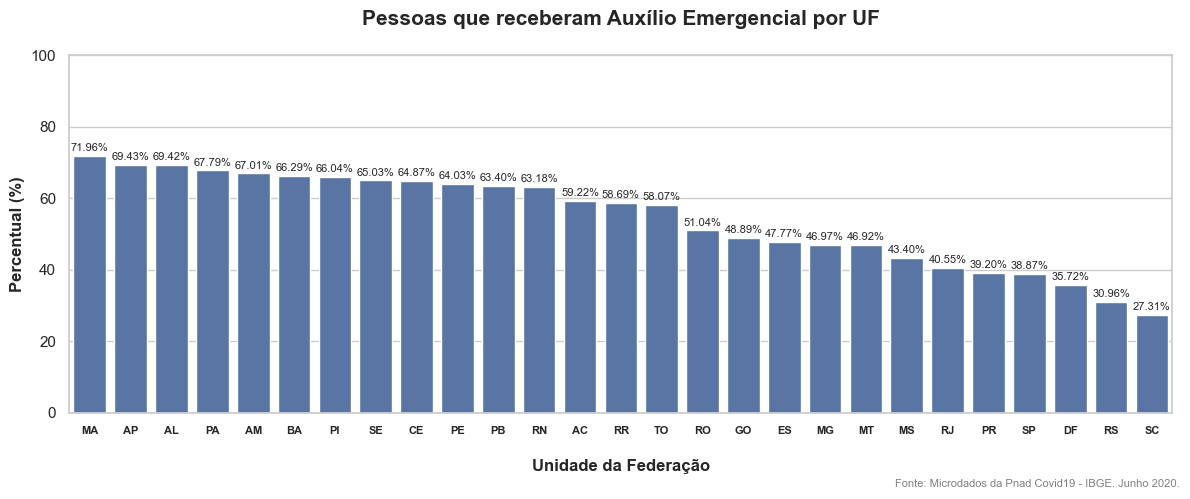

In [59]:

# Área de plotagem
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Gráfico de barras
ax = sns.barplot(
    data=df_unido,
    x='UF',
    y='%_Pessoas_Auxilio'
)

# Adiciona os rótulos de percentual em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=8, padding=2)

# Ajustes de layout e estilo
ax.set_xlabel("\nUnidade da Federação", fontsize=12, fontweight='bold')
ax.set_ylabel("Percentual (%)", fontsize=12, fontweight='bold')
ax.set_title("Pessoas que receberam Auxílio Emergencial por UF\n", \
             fontsize=15, fontweight='bold')
ax.set_xticklabels(df_unido['UF'], fontsize=8, fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()

# Adiciona a fonte como texto no rodapé
plt.figtext(0.99, 0.01, "Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.",
            horizontalalignment='right', fontsize=8, color='gray')


# Salva o gráfico em PNG
#plt.savefig("auxilio_domicilio_ssa.png", dpi=120)
#plt.show()

### <font color='blue'>**5.2) GRÁFICO: "AUXÍLIO EMERGENCIAL P/ SEXO E COR":**

#### <font color='blue'>*• Query (Tabela):*</font>

In [60]:
# Criando um dataframe para conferir pessoas que recebem Auxílio Emergencial

auxilio_cor_sexo = df[['COR', 'SEXO', 'AUXILIO_EMERGENCIAL']][df['AUXILIO_EMERGENCIAL']==1].\
    groupby(['COR', 'SEXO']).count().\
        sort_values(by='COR', ascending=True)

auxilio_cor_sexo

AUXILIO_EMERGENCIAL
COR      SEXO                       
Branca   Homem                 30357
         Mulher                33155
Preta    Homem                  8718
         Mulher                 8756
Amarela  Homem                   445
         Mulher                  512
Parda    Homem                 54012
         Mulher                56765
Indígena Homem                   417
         Mulher                  507
Ignorado Homem                    24
         Mulher                   16

In [61]:
# Criando um dataframe para conferir o total de entrevistados

entrevistado_cor_sexo = df[['COR', 'SEXO', 'COUNT']][df['COUNT']==1].\
    groupby(['COR', 'SEXO']).count().\
        sort_values(by='COR', ascending=True)

entrevistado_cor_sexo

COUNT
COR      SEXO         
Branca   Homem   75321
         Mulher  84566
Preta    Homem   15566
         Mulher  15743
Amarela  Homem    1107
         Mulher   1242
Parda    Homem   90358
         Mulher  95782
Indígena Homem     682
         Mulher    805
Ignorado Homem      57
         Mulher     41

In [62]:
# Unindo os dois dataframes anteriores

df_unido = pd.merge(auxilio_cor_sexo, entrevistado_cor_sexo, on=['COR', 'SEXO'], how='outer')
df_unido

AUXILIO_EMERGENCIAL  COUNT
COR      SEXO                              
Branca   Homem                 30357  75321
         Mulher                33155  84566
Preta    Homem                  8718  15566
         Mulher                 8756  15743
Amarela  Homem                   445   1107
         Mulher                  512   1242
Parda    Homem                 54012  90358
         Mulher                56765  95782
Indígena Homem                   417    682
         Mulher                  507    805
Ignorado Homem                    24     57
         Mulher                   16     41

In [63]:
# Calculando o percentual de pessoas com auxílio emergencial dentre os entrevistados
df_unido['%_Pessoas_Auxilio'] = (df_unido['AUXILIO_EMERGENCIAL'] / df_unido['COUNT']) * 100

# Visualizando o resultado
df_unido = df_unido.reset_index()
df_unido

,COR,SEXO,AUXILIO_EMERGENCIAL,COUNT,%_Pessoas_Auxilio
0,Branca,Homem,30357,75321,40.303501
1,Branca,Mulher,33155,84566,39.206064
2,Preta,Homem,8718,15566,56.006681
3,Preta,Mulher,8756,15743,55.618370
4,Amarela,Homem,445,1107,40.198735
5,Amarela,Mulher,512,1242,41.223833
6,Parda,Homem,54012,90358,59.775559
7,Parda,Mulher,56765,95782,59.264789
8,Indígena,Homem,417,682,61.143695
9,Indígena,Mulher,507,805,62.981366


In [64]:
# Exluindo os índices correspondentes aos 'Ignorados'

df_unido = df_unido.drop(df_unido[(df_unido['COR'] == 'Ignorado')].index)
df_unido.reset_index(drop=True, inplace=True)
df_unido['COR'] = df_unido['COR'].cat.remove_unused_categories() # Para essa core ñ apareca no gráfico!
df_unido

,COR,SEXO,AUXILIO_EMERGENCIAL,COUNT,%_Pessoas_Auxilio
0,Branca,Homem,30357,75321,40.303501
1,Branca,Mulher,33155,84566,39.206064
2,Preta,Homem,8718,15566,56.006681
3,Preta,Mulher,8756,15743,55.618370
4,Amarela,Homem,445,1107,40.198735
5,Amarela,Mulher,512,1242,41.223833
6,Parda,Homem,54012,90358,59.775559
7,Parda,Mulher,56765,95782,59.264789
8,Indígena,Homem,417,682,61.143695
9,Indígena,Mulher,507,805,62.981366


#### <font color='blue'>*• Plot:*</font>

Text(0.99, 0.01, 'Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.')

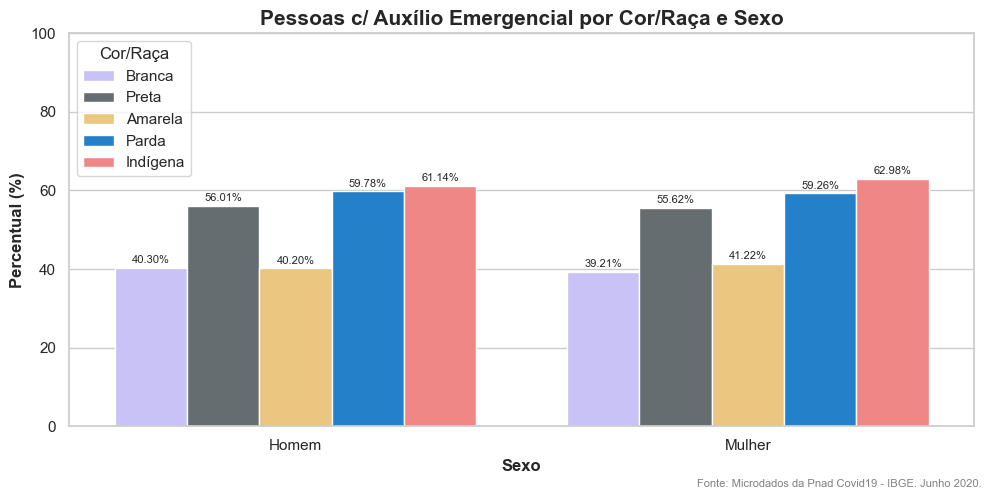

In [65]:
# Gráfico

# Área de Plotagem
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Gráfico de barras agrupadas
ax = sns.barplot(
    data=df_unido,
    x='SEXO',
    y='%_Pessoas_Auxilio',
    hue='COR',
    palette=["#c1b9ff", "#636e72",  "#fdcb6e", "#0984e3", "#ff7675"]
)

# Adiciona os rótulos de percentual em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=8, padding=2)

# Ajustes de layout e estilo
ax.set_xlabel("Sexo", fontsize=12, fontweight='bold')
ax.set_ylabel("Percentual (%)", fontsize=12, fontweight='bold')
ax.set_title("Pessoas c/ Auxílio Emergencial por Cor/Raça e Sexo", \
             fontsize=15, fontweight='bold')
ax.legend(title="Cor/Raça", loc='upper left')
plt.ylim(0, 100)
plt.tight_layout()

# Adiciona a fonte como texto no rodapé
plt.figtext(0.99, 0.01, "Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.", 
            horizontalalignment='right', fontsize=8, color='gray')


# Salva o gráfico em PNG
#plt.savefig("auxilio_cor_sexo_ssa.png", dpi=120)
#plt.show()

### <font color='blue'>**5.3) GRÁFICO: "AUXÍLIO EMERGENCIAL P/ FAIXA SALARIAL"</font>**

#### <font color='blue'>*• Criando uma nova variável no final do dataframe 'df' p/ segmentar as faixas salariais:*</font>

In [66]:
# Adicionando uma nova coluna ao dataframe

df['FAIXA_SALARIO'] = df['SALARIO']

In [67]:
# Vendo as primeiras linhas da coluna FAIXA_SALARIO

df['FAIXA_SALARIO'].head()

0    1045.0
1    1045.0
2       0.0
3       0.0
4       0.0
Name: FAIXA_SALARIO, dtype: float64

In [68]:
# Valor Mínimo e Valor Máximo

# df.FAIXA_SALARIO.describe()

print(df['FAIXA_SALARIO'].min())
print(df['FAIXA_SALARIO'].max())

0.0
200000.0


In [69]:
# Convertendo a variável FAIXA_SALARIO para categórica, onde:
#
# de 0 a 1044 = "Menos de um salário mínimo", 
# de 1045 a 2090 = "Entre 1 e 2", 
# de 2091 a 3135 = "Entre 2 e 3", 
# de 3136 a 4180 = "Entre 3 e 4", 
# de 4181 a 5225 = "Entre 4 e 5"
# + que 5226 = "Mais de 5"

df['FAIXA_SALARIO'] = pd.cut(df['FAIXA_SALARIO'], \
    bins=[-1, 1044, 2090, 3135, 4180, 5225, 250000], \
    labels=['Menos de um salário mínimo', \
            'Entre 1 e 2', \
                'Entre 2 e 3', \
                 'Entre 3 e 4', \
                    'Entre 4 e 5', \
                        'Mais de 5'])

df['FAIXA_SALARIO'].head()

0                   Entre 1 e 2
1                   Entre 1 e 2
2    Menos de um salário mínimo
3    Menos de um salário mínimo
4    Menos de um salário mínimo
Name: FAIXA_SALARIO, dtype: category
Categories (6, object): ['Menos de um salário mínimo' < 'Entre 1 e 2' < 'Entre 2 e 3' < 'Entre 3 e 4' < 'Entre 4 e 5' < 'Mais de 5']

#### <font color='blue'>*• Query (Tabela):*</font>

In [70]:
# Criando um dataframe para conferir pessoas que recebem Auxílio Emergencial

auxilio_renda = df[['FAIXA_SALARIO', 'AUXILIO_EMERGENCIAL']][df['AUXILIO_EMERGENCIAL']==1].\
    groupby('FAIXA_SALARIO').count().\
        sort_values(by='FAIXA_SALARIO', ascending=True)

auxilio_renda

,AUXILIO_EMERGENCIAL
FAIXA_SALARIO,
Menos de um salário mínimo,153042
Entre 1 e 2,32305
Entre 2 e 3,5257
Entre 3 e 4,1508
Entre 4 e 5,745
Mais de 5,827


In [71]:
# Criando um dataframe para conferir o total de entrevistados

entrevistado_renda = df[['FAIXA_SALARIO', 'COUNT']][df['COUNT']==1].\
    groupby('FAIXA_SALARIO').count().\
        sort_values(by='FAIXA_SALARIO', ascending=True)

entrevistado_renda

,COUNT
FAIXA_SALARIO,
Menos de um salário mínimo,271030
Entre 1 e 2,71666
Entre 2 e 3,17403
Entre 3 e 4,7087
Entre 4 e 5,4918
Mais de 5,9166


In [72]:
# Unindo os dois dataframes anteriores

df_unido = pd.merge(auxilio_renda, entrevistado_renda, on='FAIXA_SALARIO', how='outer')
df_unido

,AUXILIO_EMERGENCIAL,COUNT
FAIXA_SALARIO,,
Menos de um salário mínimo,153042,271030
Entre 1 e 2,32305,71666
Entre 2 e 3,5257,17403
Entre 3 e 4,1508,7087
Entre 4 e 5,745,4918
Mais de 5,827,9166


In [73]:
# Calculando o percentual de pessoas c/ auxilio emergencial dentre os entrevistados
df_unido['%_Pessoas_Auxilio'] = (df_unido['AUXILIO_EMERGENCIAL'] / df_unido['COUNT']) * 100

# Visualizando o resultado
df_unido = df_unido.reset_index()
df_unido

,FAIXA_SALARIO,AUXILIO_EMERGENCIAL,COUNT,%_Pessoas_Auxilio
0,Menos de um salário mínimo,153042,271030,56.466812
1,Entre 1 e 2,32305,71666,45.077164
2,Entre 2 e 3,5257,17403,30.207435
3,Entre 3 e 4,1508,7087,21.278397
4,Entre 4 e 5,745,4918,15.148434
5,Mais de 5,827,9166,9.022474


#### <font color='blue'>*• Plot:*</font>

Text(0.99, 0.01, 'Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.')

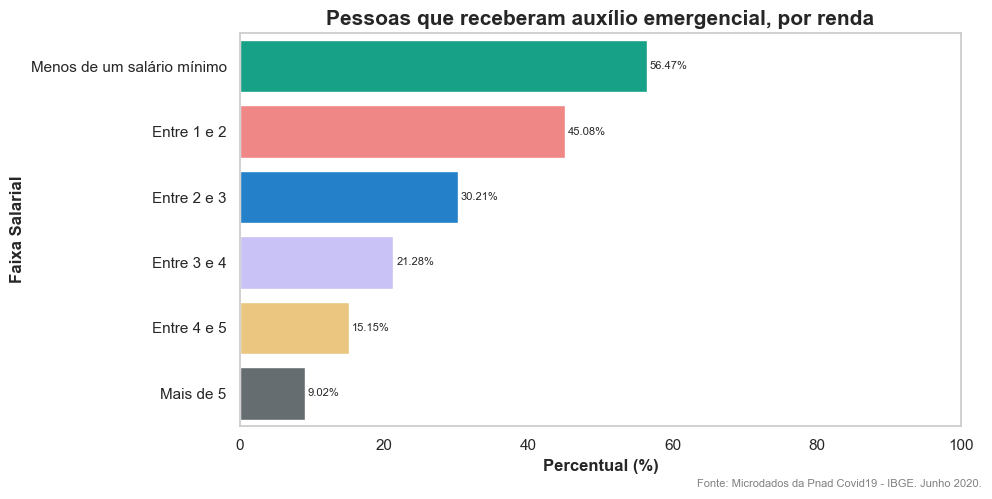

In [74]:

# Área de plotagem
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Gráfico de barras horizontal (barh)
ax = sns.barplot(
    data=df_unido,
    y='FAIXA_SALARIO',
    x='%_Pessoas_Auxilio',
    palette=["#00b894","#ff7675","#0984e3","#c1b9ff","#fdcb6e","#636e72"],
    orient='h'
)

# Remove as linhas de grade
ax.grid(False)

# Adiciona os rótulos de percentual em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=8, padding=2)

# Ajustes de layout e estilo
ax.set_xlabel("Percentual (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Faixa Salarial", fontsize=12, fontweight='bold')
ax.set_title("Pessoas que receberam auxílio emergencial, por renda", fontsize=15, \
             fontweight='bold')
ax.set_xlim(0, 100)
plt.tight_layout()

# Adiciona a fonte como texto no rodapé
plt.figtext(0.99, 0.01, "Fonte: Microdados da Pnad Covid19 - IBGE. Junho 2020.",
            horizontalalignment='right', fontsize=8, color='gray')

# Salva o gráfico em PNG
#plt.savefig("auxilio_renda_ssa.png", dpi=120)
#plt.show()

#### <font color='blue'>*• Exluindo a variável c/ as faixas salariais e tb a variável contadora 'COUNT' p/ não interferir no modelo preditivo:*</font>

In [75]:
df= df.drop(['COUNT', 'FAIXA_SALARIO'], axis = 1)

### <font color='blue'>**5.4) VERIFICANDO SE A CLASSE PREDITORA ESTÁ DESBALANCEADA:**

#### <font color='blue'>*• Verificando a proporção dos que **RECEBEM** o Auxílio Emergencial e dos que **NÃO RECEBEM**:*</font>

In [76]:
# Mostrando a quantidade de pessoas COM AUXÍLIO EMERGENCIAL (=1) e a quantidade de pessoas SEM AUXÍLIO EMERGENCIAL (=2)
df['AUXILIO_EMERGENCIAL'].value_counts()

AUXILIO_EMERGENCIAL
1    193684
2    187586
Name: count, dtype: int64

In [77]:
# Mostrando a porcentagem dos que TÊM Auxílio Emergencial (classe preditora) e dos que NÃO TÊM
df['AUXILIO_EMERGENCIAL'].value_counts(normalize=True) # O padrão é 'False' (valores absolutos)

AUXILIO_EMERGENCIAL
1    0.507997
2    0.492003
Name: proportion, dtype: float64

<Axes: xlabel='AUXILIO_EMERGENCIAL', ylabel='count'>

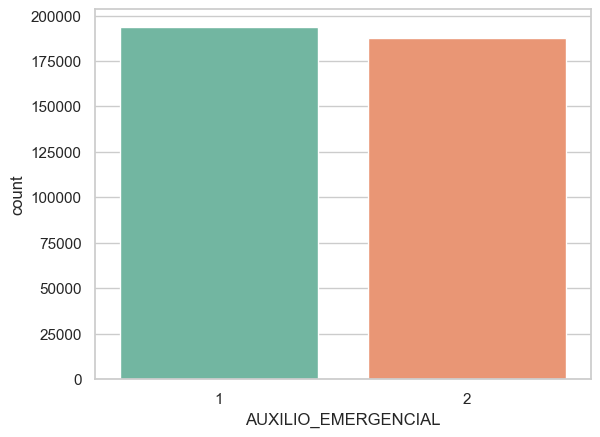

In [78]:
# Fazendo um gráfico para mostrar a quantidade de registros em cada classe
sns.countplot(x='AUXILIO_EMERGENCIAL', data=df, palette='Set2')

### <font color='blue'>**5.5) OUTROS GRÁFICOS P/ ANÁLISE DAS DISTRIBUIÇÕES E OUTLIERS:**

#### <font color='blue'>*• Automatizando a criação de **Boxplots** (variáveis numéricas) e **Gráf de Barras** (categóricas):*</font>

In [79]:
# Análise Exploratória de Dados (EDA)

# Função criada p/ automatizar a criação dos gráficos
def eda(dados):
    
    for column in dados.columns:
        
        # Se a coluna for numérica (faremos um boxplot)
        if dados[column].dtype in ['int64', 'float64']:
            
            # Histograma e Boxplot
            fig, axes = plt.subplots(1, 2)
            sns.histplot(dados[column], kde = True, ax = axes[0])
            sns.boxplot(x = 'AUXILIO_EMERGENCIAL', y = column, data = dados, ax = axes[1])
            axes[0].set_title(f'Distribuição de {column}')
            axes[1].set_title(f'{column} vs AUXILIO_EMERGENCIAL')
            plt.tight_layout()
            plt.show()
            
        # Se a coluna for categórica (faremos gráfico de barras)
        else:
            
            # Contagem de frequência e relação com AUXILIO_EMERGENCIAL
            fig, axes = plt.subplots(1, 2)
            sns.countplot(x = column, data = dados, ax = axes[0])
            sns.countplot(x = column, hue = 'AUXILIO_EMERGENCIAL', data = dados, ax = axes[1])
            axes[0].set_title(f'Distribuição de {column}')
            axes[1].set_title(f'{column} vs AUXILIO_EMERGENCIAL')
            plt.tight_layout()
            plt.show()

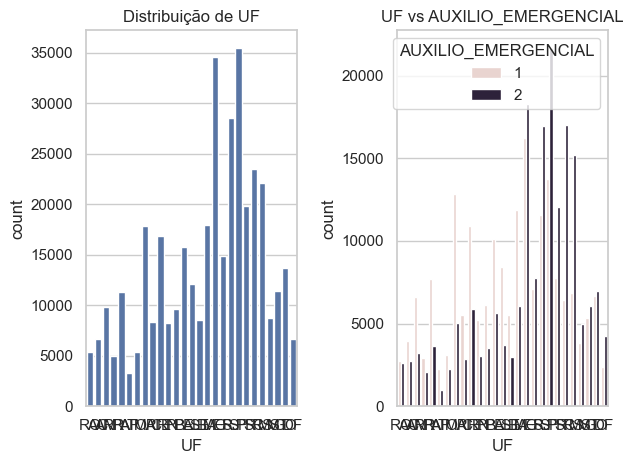

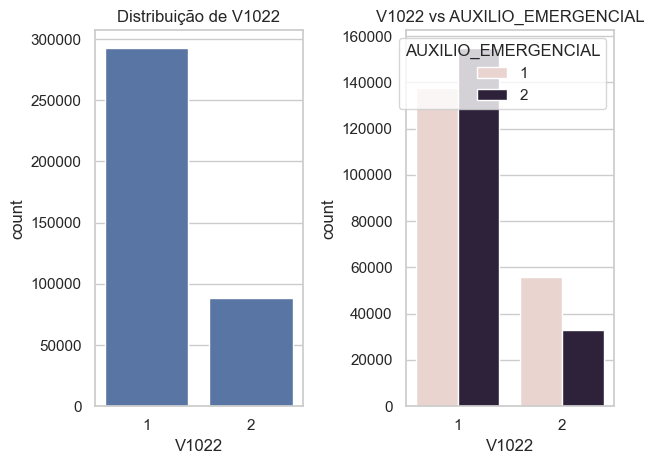

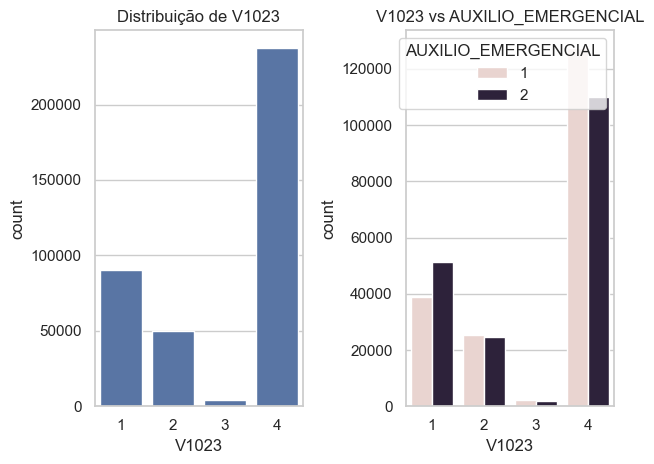

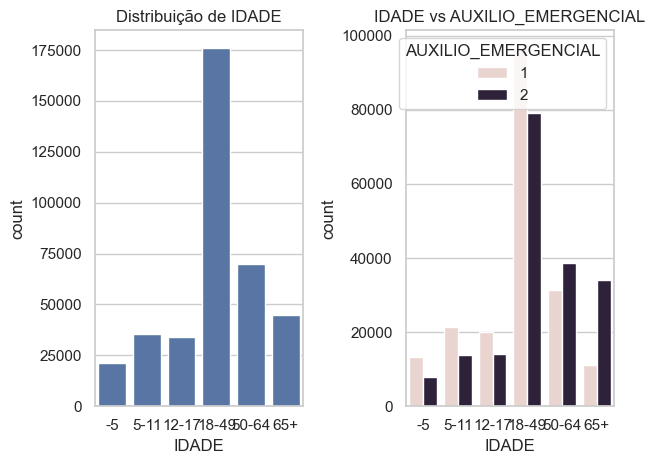

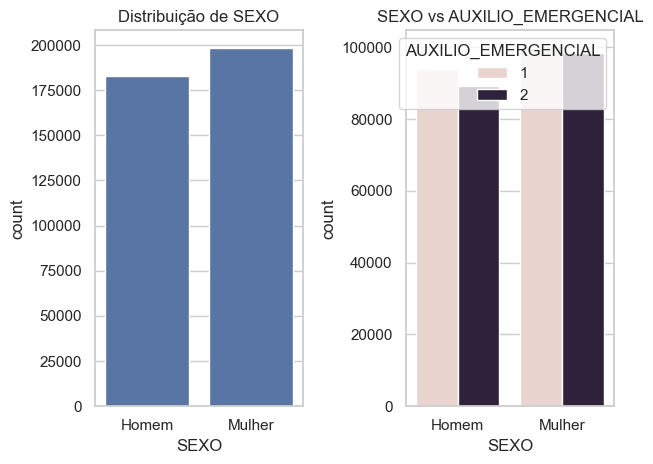

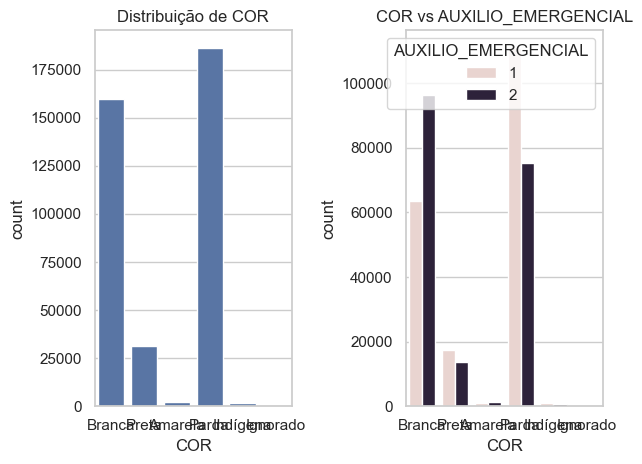

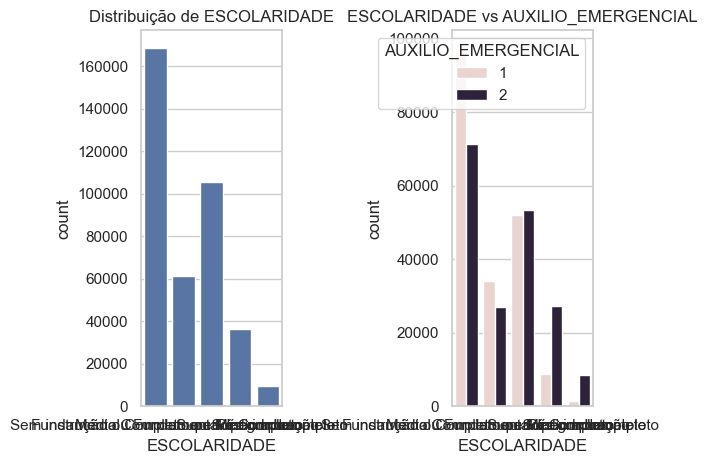

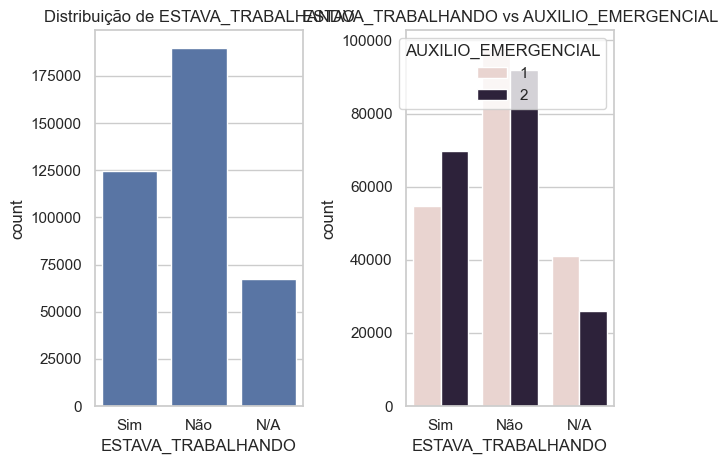

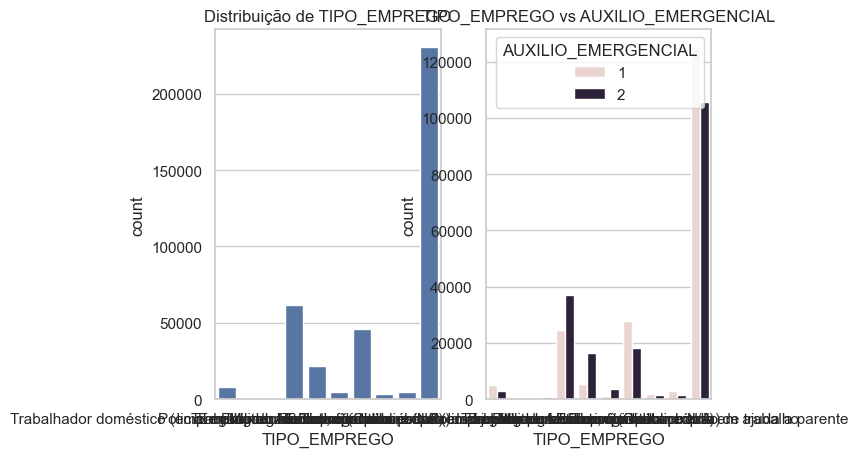

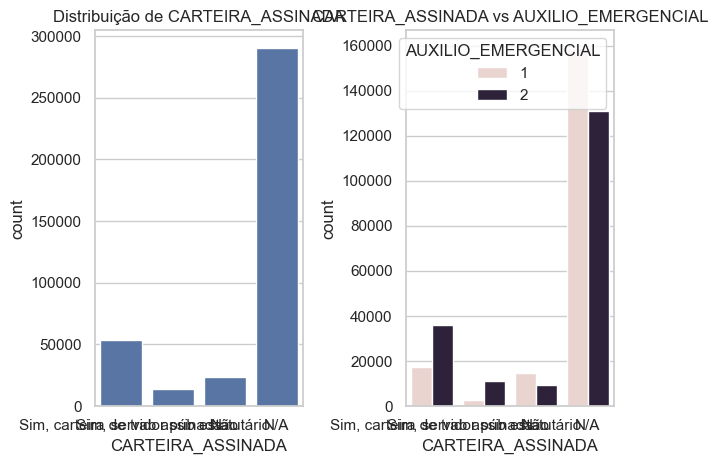

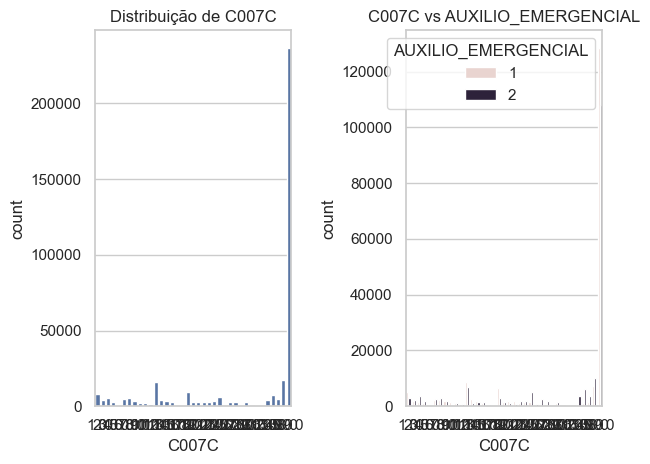

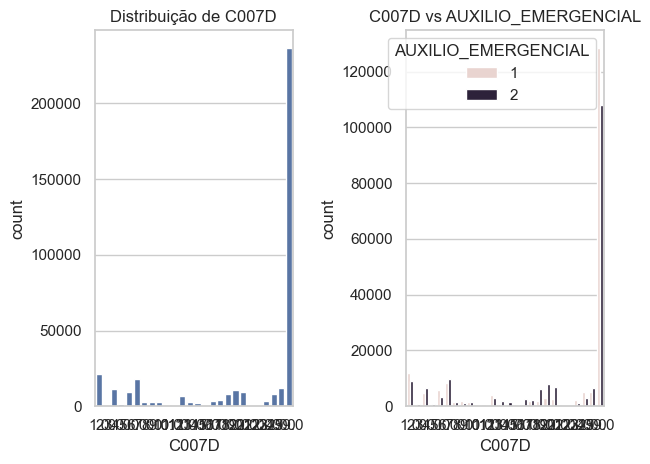

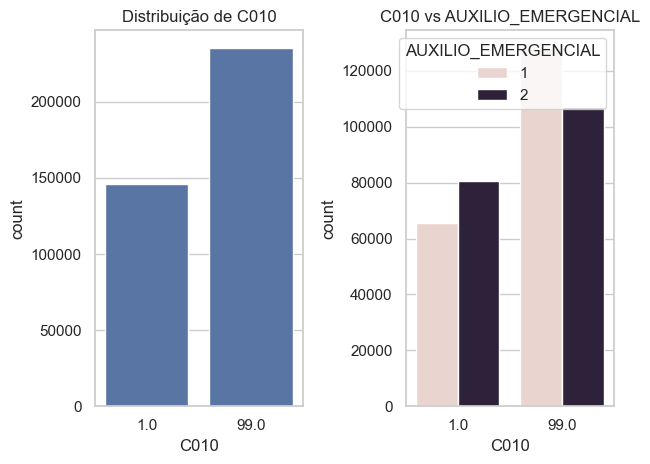

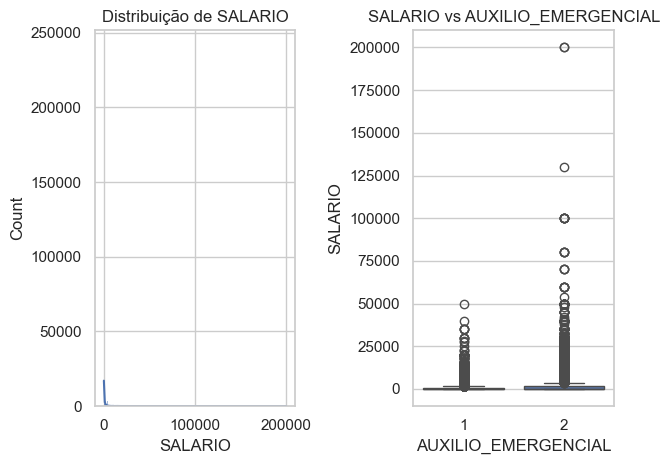

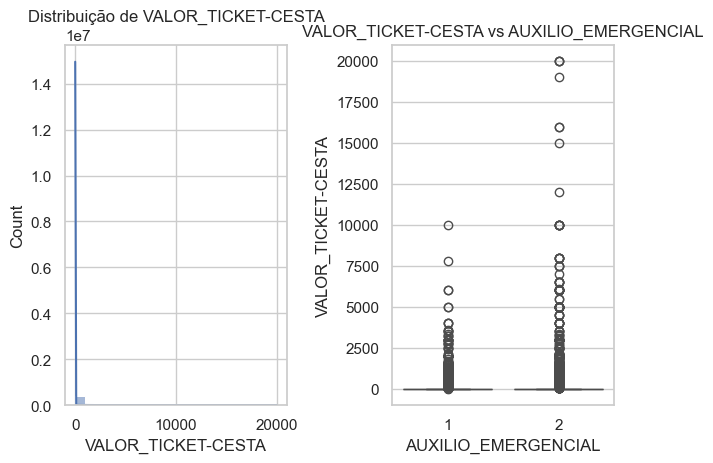

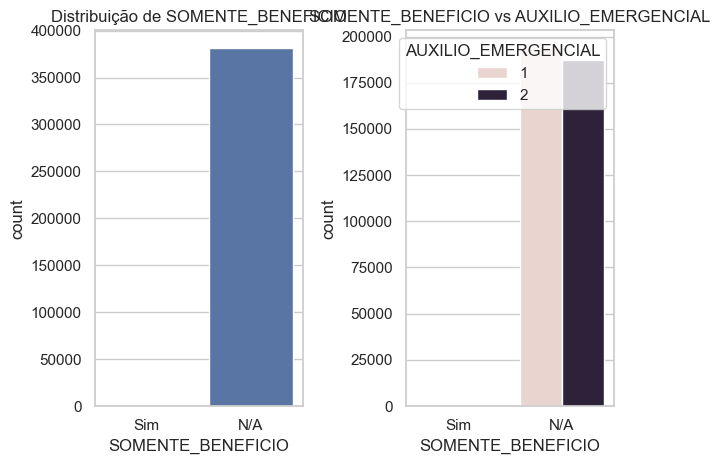

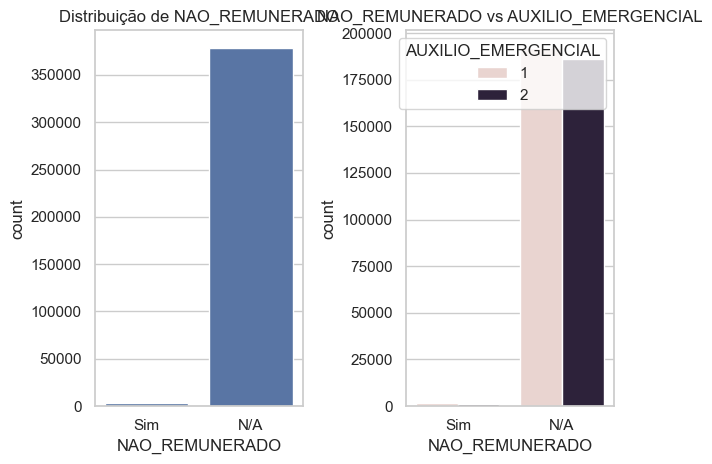

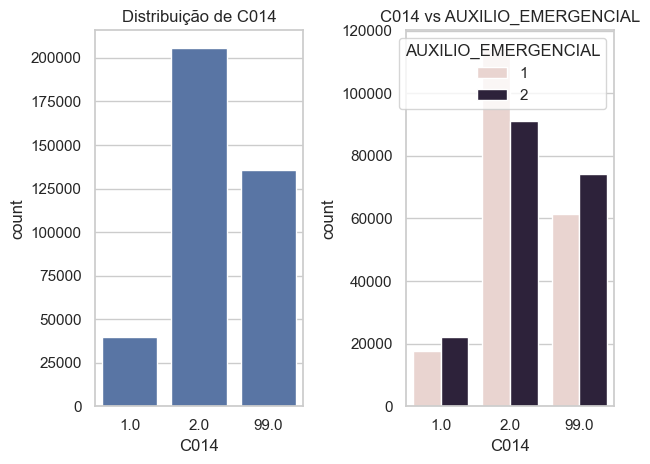

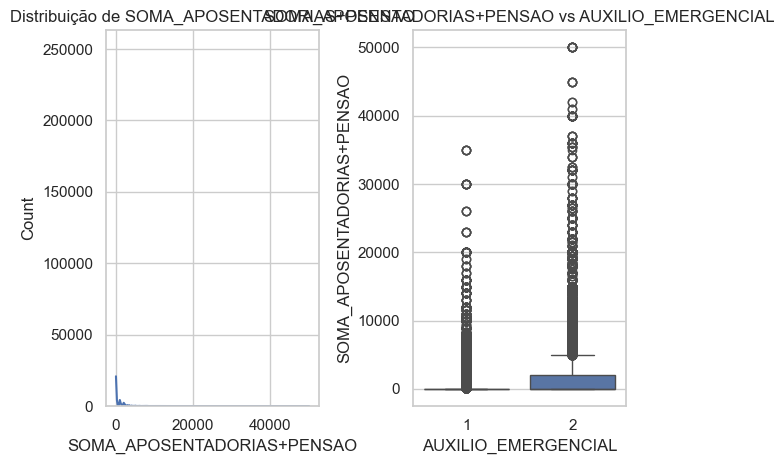

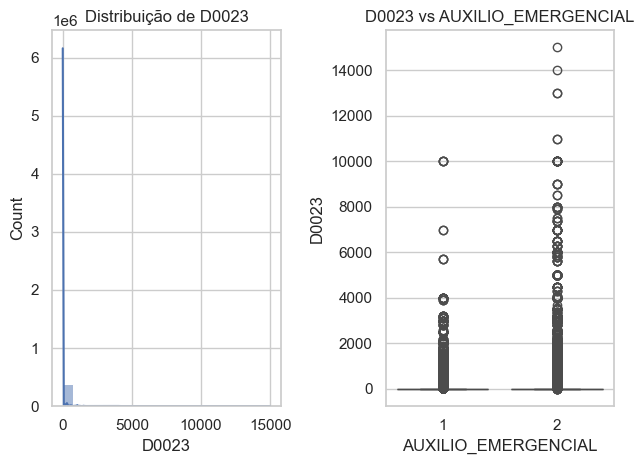

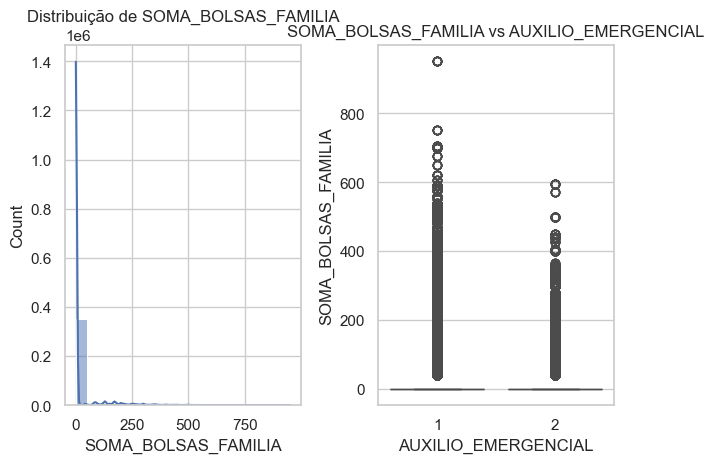

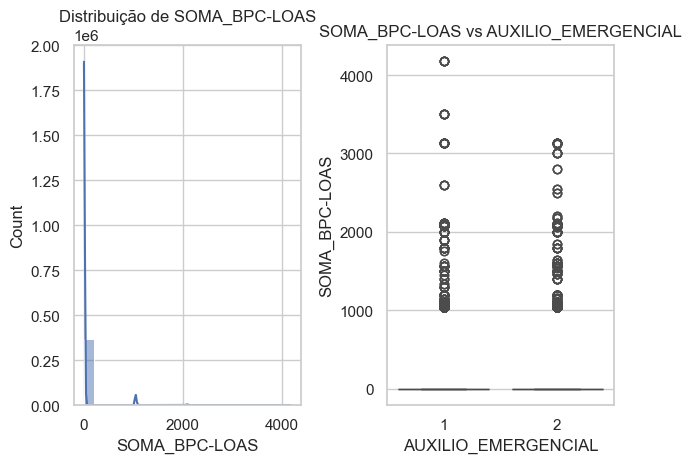

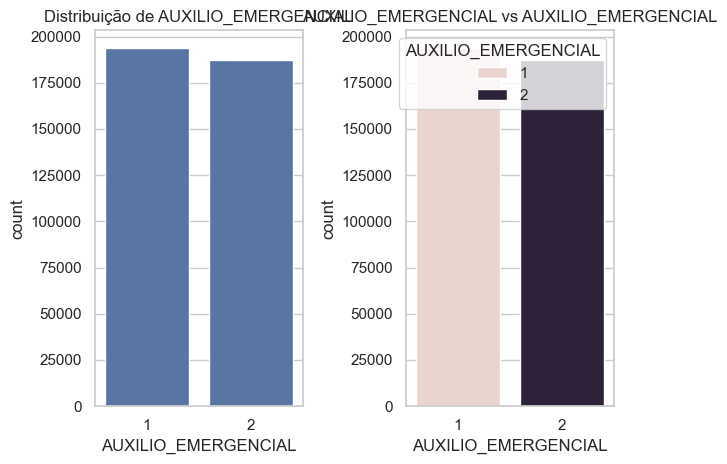

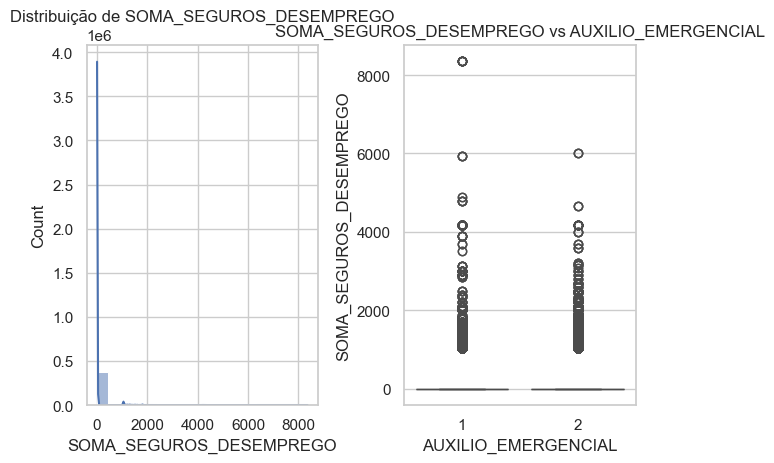

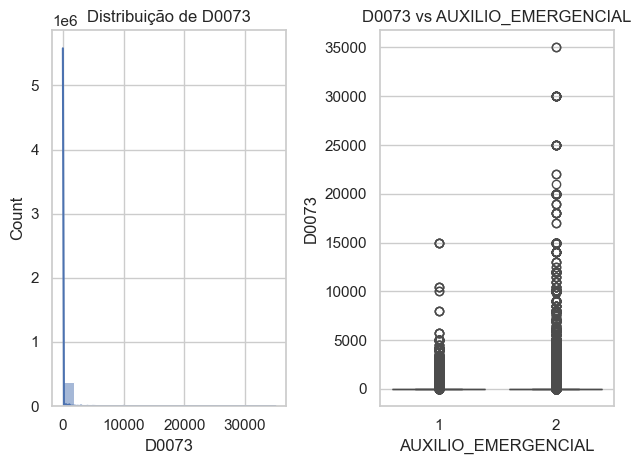

In [80]:
# Realizando a EDA (Análise Exploratória de Dados)

# Ao chamar a função criada na célula acima, estaremos criando um gráfico para cada coluna do dataframe.
# Dentre outras, isso nos ajudará a responder às seguintes perguntas:

# 1) Quais colunas (variáveis) iremos lançar mão para seguir adiante com nosso modelo preditivo?
# 2) Existe algum problema/anomalia ou outliers?
# 3) Preciso investigar mais a fundo alguma variável?

eda(df)

## <font color='gray'>**6) Divisão Treino-Teste:**

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381270 entries, 0 to 381269
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   UF                          381270 non-null  category
 1   V1022                       381270 non-null  category
 2   V1023                       381270 non-null  category
 3   IDADE                       381270 non-null  category
 4   SEXO                        381270 non-null  category
 5   COR                         381270 non-null  category
 6   ESCOLARIDADE                381270 non-null  category
 7   ESTAVA_TRABALHANDO          381270 non-null  category
 8   TIPO_EMPREGO                381270 non-null  category
 9   CARTEIRA_ASSINADA           381270 non-null  category
 10  C007C                       381270 non-null  category
 11  C007D                       381270 non-null  category
 12  C010                        381270 non-null  category
 13 

In [82]:
# Divisão em Treino e Teste

valor_test_size = 0.3
X = df.drop(columns = ['AUXILIO_EMERGENCIAL'], axis = 1)  # Matriz contendo "todo" o dataframe, menos a variável alvo
y = df['AUXILIO_EMERGENCIAL']  # Vetor contendo a variável target (rótulo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = valor_test_size, random_state = 42)

In [83]:
# 'Recebem Auxilio' X 'Não recebem Auxilio' na tabela de Treino

y_train.value_counts()

AUXILIO_EMERGENCIAL
1    135679
2    131210
Name: count, dtype: int64

In [84]:
# Mostrando em porcentagem

y_train.value_counts(normalize=True) # O padrão é 'False' (valores absolutos)

AUXILIO_EMERGENCIAL
1    0.508372
2    0.491628
Name: proportion, dtype: float64

In [85]:
# Verificando o tamanho dos conjuntos de Treino e Teste

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((266889, 24), (114381, 24), (266889,), (114381,))

## <font color='gray'>**7) Pré-processamento/Padronização (Preparando p/ o algoritmo):**

#### <font color='gray'>*• Convertendo as variáveis categóricas em numéricas e usando o **One-Hot Encoding**:*

In [86]:
# Amostra dos dados

df.head()

,UF,V1022,V1023,IDADE,SEXO,COR,ESCOLARIDADE,ESTAVA_TRABALHANDO,TIPO_EMPREGO,CARTEIRA_ASSINADA,...,SOMENTE_BENEFICIO,NAO_REMUNERADO,C014,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,AUXILIO_EMERGENCIAL,SOMA_SEGUROS_DESEMPREGO,D0073
0,RO,1,1,18-49,Homem,Parda,Médio Completo ou Superior Incompleto,Sim,Empregado do setor privado,"Sim, carteira de trab assinada",...,N/A,N/A,99.0,0.0,0.0,0.0,0.0,1,0.0,0.0
1,RO,1,1,18-49,Mulher,Parda,Superior Completo,Não,Autônomo (Conta própria),N/A,...,N/A,N/A,2.0,0.0,0.0,0.0,0.0,1,0.0,0.0
2,RO,1,1,12-17,Homem,Parda,Sem instrução ou Fundamental Incompleto,N/A,N/A,N/A,...,N/A,N/A,99.0,0.0,0.0,0.0,0.0,1,0.0,0.0
3,RO,1,1,5-11,Homem,Parda,Sem instrução ou Fundamental Incompleto,N/A,N/A,N/A,...,N/A,N/A,99.0,0.0,0.0,0.0,0.0,1,0.0,0.0
4,RO,1,1,50-64,Mulher,Branca,Sem instrução ou Fundamental Incompleto,Não,N/A,N/A,...,N/A,N/A,2.0,0.0,0.0,0.0,1045.0,2,0.0,0.0


In [87]:
# Selecionando as variáveis categóricas (e armazenando numa lista do pandas)
categorical_cols = df.select_dtypes(include = ['category']).columns
categorical_cols

Index(['UF', 'V1022', 'V1023', 'IDADE', 'SEXO', 'COR', 'ESCOLARIDADE',
       'ESTAVA_TRABALHANDO', 'TIPO_EMPREGO', 'CARTEIRA_ASSINADA', 'C007C',
       'C007D', 'C010', 'SOMENTE_BENEFICIO', 'NAO_REMUNERADO', 'C014'],
      dtype='object')

In [88]:
# Aplicando One-Hot Encoding separadamente aos conjuntos de treino e teste

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Obs: Está sendo criado o objeto 'encoder', como uma instância da classe OneHotEncoder() do sklearn
# Será usado para transformar variáveis categóricas em numéricas com o One-Hot Encoding

# sparse_output=False: o resultado será um DataFrame/array denso, não esparso
# handle_unknown='ignore': categorias desconhecidas nos dados de teste serão ignoradas (não causam erro).

In [89]:
# Treinando o objeto "encoder" com o conjunto de treino e transformando ambos (treino e teste)

X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_cols]))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_cols]))


In [90]:
X_train_encoded.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [91]:
X_test_encoded.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [92]:
# Renomeando as colunas para corresponderem aos nomes das categorias

X_train_encoded.columns = encoder.get_feature_names_out(categorical_cols)
X_test_encoded.columns = encoder.get_feature_names_out(categorical_cols)

In [93]:
X_train_encoded.head()

,UF_AC,UF_AL,UF_AM,UF_AP,UF_BA,UF_CE,UF_DF,UF_ES,UF_GO,UF_MA,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [94]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266889 entries, 0 to 266888
Columns: 141 entries, UF_AC to C014_99.0
dtypes: float64(141)
memory usage: 287.1 MB


In [95]:
# Removendo as colunas categóricas originais e adicionando as codificadas nos dados de Treino

X_train_preprocessed = X_train.drop(categorical_cols, axis = 1).reset_index(drop = True)
X_train_preprocessed = pd.concat([X_train_preprocessed, X_train_encoded], axis = 1)

In [96]:
# Visualizando as primeiras linhas dos dados de treino pré-processados
X_train_preprocessed.head()

,SALARIO,VALOR_TICKET-CESTA,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,SOMA_SEGUROS_DESEMPREGO,D0073,UF_AC,UF_AL,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,1045.0,0.0,1045.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1045.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1100.0,0.0,0.0,0.0,0.0,1045.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,212.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,800.0,0.0,2090.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


<span style="background-color: rgb(241, 249, 126); color: blue;">*Toda e qualquer transformação aplicada aos dados de treino, deve ser aplicada aos dados de teste e aos novos dados.*

In [97]:
# Removendo as colunas categóricas originais e adicionando as codificadas nos dados de Teste

X_test_preprocessed = X_test.drop(categorical_cols, axis = 1).reset_index(drop = True)
X_test_preprocessed = pd.concat([X_test_preprocessed, X_test_encoded], axis = 1)

In [98]:
# Visualizando as primeiras linhas dos dados de teste após o pré-processamento
X_test_preprocessed.head()

,SALARIO,VALOR_TICKET-CESTA,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,SOMA_SEGUROS_DESEMPREGO,D0073,UF_AC,UF_AL,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,2100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2400.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


#### <font color='gray'>*• Padronizando os dados para que estejam na mesma escala, usando o **StandardScaler**:*
*( Não é necessário no RandomForest, mas faremos para aprender )*

In [99]:
# Criando uma lista pandas para receber os nomes das colunas com valores numéricos (int64 e float64), exceto a variável alvo (int32)

numeric_cols = X_train_preprocessed.select_dtypes(include = ['int64', 'float64']).columns

print(numeric_cols)


Index(['SALARIO', 'VALOR_TICKET-CESTA', 'SOMA_APOSENTADORIAS+PENSAO', 'D0023',
       'SOMA_BOLSAS_FAMILIA', 'SOMA_BPC-LOAS', 'SOMA_SEGUROS_DESEMPREGO',
       'D0073', 'UF_AC', 'UF_AL',
       ...
       'C007D_99.0', 'C010_1.0', 'C010_99.0', 'SOMENTE_BENEFICIO_N/A',
       'SOMENTE_BENEFICIO_Sim', 'NAO_REMUNERADO_N/A', 'NAO_REMUNERADO_Sim',
       'C014_1.0', 'C014_2.0', 'C014_99.0'],
      dtype='object', length=149)


In [100]:
# Criando o StandardScaler

scaler = StandardScaler()

# Obs: Está sendo criado o objeto 'scaler', como uma instância da classe StandardScaler() do sklearn
# Ele servirá p/ deixar todas as colunas numéricas com média 0 e desvio padrão = 1

In [101]:
# Aplicando o StandardScaler às variáveis numéricas

X_train_preprocessed[numeric_cols] = scaler.fit_transform(X_train_preprocessed[numeric_cols])
X_test_preprocessed[numeric_cols] = scaler.transform(X_test_preprocessed[numeric_cols])

In [102]:
# Visualizando as primeiras linhas dos datasets de treino e teste após pré-processamento
X_train_preprocessed.head()

,SALARIO,VALOR_TICKET-CESTA,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,SOMA_SEGUROS_DESEMPREGO,D0073,UF_AC,UF_AL,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,0.106581,-0.032049,0.143776,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
1,-0.386797,-0.032049,0.143776,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
2,0.132548,-0.032049,-0.432151,-0.129761,-0.270754,4.805993,-0.136021,-0.122749,7.412933,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597
3,-0.386797,-0.032049,-0.432151,-0.129761,3.165902,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597
4,-0.009092,-0.032049,0.719703,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,2.912440,-1.080747,-0.743165


<span style="background-color: rgb(241, 249, 126); color: blue;">*Toda e qualquer transformação aplicada aos dados de treino, deve ser aplicada aos dados de teste e aos novos dados (nestes 2 últimos, sem o *".fit"*)*

In [103]:
X_test_preprocessed.head()

,SALARIO,VALOR_TICKET-CESTA,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,SOMA_SEGUROS_DESEMPREGO,D0073,UF_AC,UF_AL,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,-0.386797,-0.032049,-0.432151,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
1,-0.386797,-0.032049,-0.432151,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
2,-0.386797,-0.032049,1.772355,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
3,-0.386797,-0.032049,0.725215,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597
4,0.746319,-0.032049,-0.432151,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,7.412933,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597


## <font color='blue'>**8) Instanciando/ Criando o modelo:**

In [104]:
# Criando o modelo RandomForest

dsa_modelo_v1 = RandomForestClassifier(random_state = 42)

## <font color='blue'>**9) Treinando o modelo:**

In [105]:
# Treinando o modelo

dsa_modelo_v1.fit(X_train_preprocessed, y_train)


# OBS: ESTE TREINAMENTO DEMOROU 2 MIN P/ SER FEITO EM MEU LENOVO CORE i5 2.40 GHz, 8Gb RAM e c/ SSD

RandomForestClassifier(random_state=42)

## <font color='blue'>**10) Avaliando/ Visualizando o modelo:**

#### <font color='blue'>*• Gráfico da **"Taxa de Erro"** da Floresta Aleatória:*</font>

In [106]:
# plotando um gráfico para mostrar a taxa de erro do modelo em função do nro de árvores de decisão

#n_trees = [10, 50, 100, 200, 300, 400, 500]
#error_rates = []
#
#for n in n_trees:
#    rf = RandomForestClassifier(n_estimators=n, random_state=42)
#    rf.fit(X_train_preprocessed, y_train)
#    y_pred = rf.predict(X_test_preprocessed)
#    error = 1 - accuracy_score(y_test, y_pred)
#    error_rates.append(error)
#
#plt.figure(figsize=(8,5))
#plt.plot(n_trees, error_rates, marker='o')
#plt.title('Taxa de Erro vs Número de Árvores (Random Forest)')
#plt.xlabel('Número de Árvores (n_estimators)')
#plt.ylabel('Taxa de Erro')
#plt.grid(True)
#plt.show()


# OBS: ESTE GRÁFICO DEMOROU 40 MIN P/ SER FEITO EM MEU LENOVO CORE i5 2.40 GHz, 8Gb RAM e c/ SSD

><font color='purple'>Como podemos observar, o modelo tem a MENOR taxa de erro EM TORNO DE  **400 árvores de decisão**. A partir daí, o modelo começa a errar mais.

#### <font color='blue'>*• Gráfico da **"Importância de Cada Variável"**:*</font>

In [107]:
# Descobrindo quais são as variáveis mais importantes do modelo
importances = dsa_modelo_v1.feature_importances_
feature_names = X_train_preprocessed.columns

# Criando um DataFrame para armazenar as importâncias
importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)
importances_df

,Feature,Importance
2,SOMA_APOSENTADORIAS+PENSAO,0.146075
0,SALARIO,0.079866
4,SOMA_BOLSAS_FAMILIA,0.054322
3,D0023,0.028237
46,IDADE_65+,0.027523
...,...,...
68,TIPO_EMPREGO_Militar,0.000148
51,COR_Ignorado,0.000139
106,C007C_30.0,0.000062
143,SOMENTE_BENEFICIO_Sim,0.000061


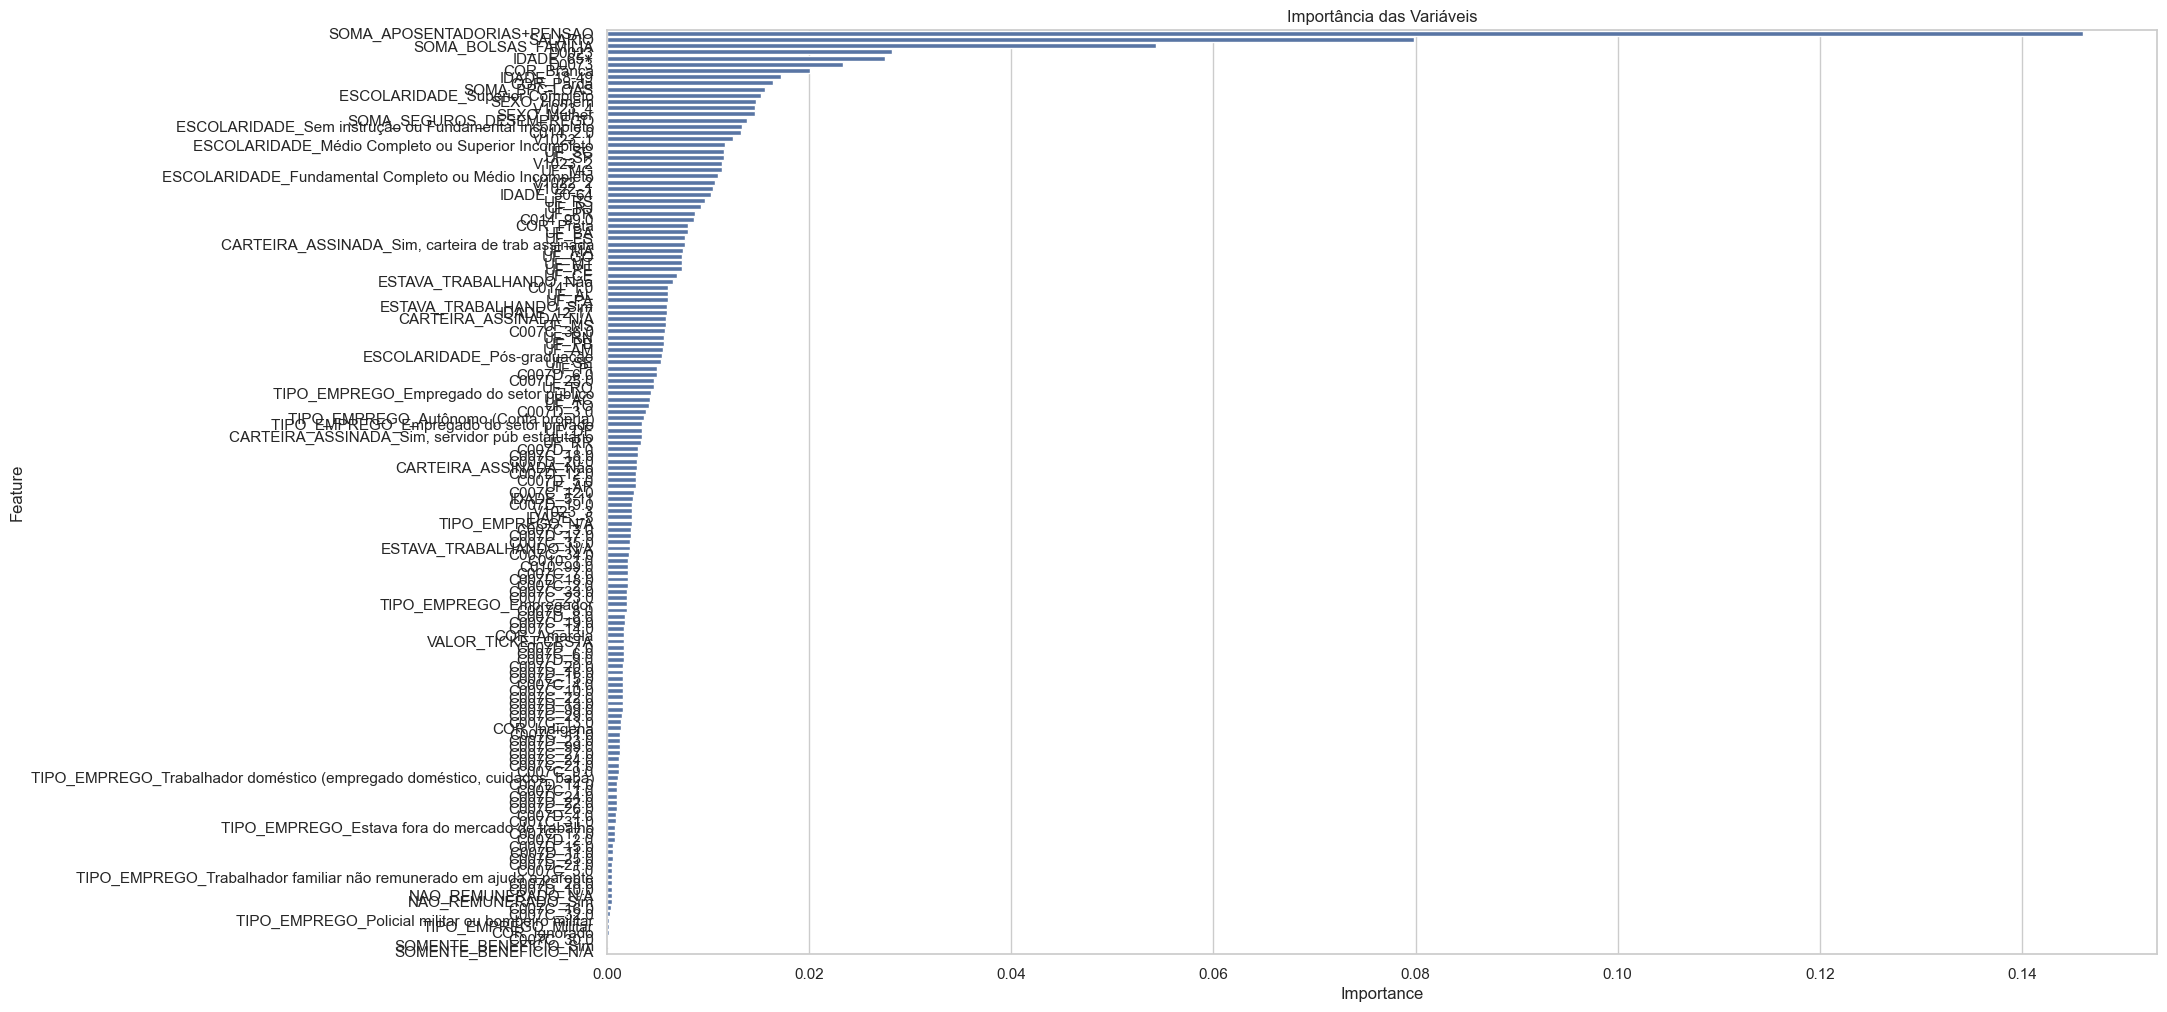

In [108]:
# Plotando o gráfico de importância das variáveis
plt.figure(figsize=(20, 12))
sns.barplot(data=importances_df, x='Importance', y='Feature')
plt.title('Importância das Variáveis')
plt.show()

#### <font color='blue'>*• Fazendo **previsões** com os dados de TESTE:*</font>

In [109]:
# Fazendo previsões no conjunto de teste (retornará um array numpy)

y_pred = dsa_modelo_v1.predict(X_test_preprocessed)
y_pred

array([2, 1, 2, ..., 2, 1, 2])

In [110]:
# Mesmo array anterior, mas contendo as probabilidades das previsões

y_pred_proba = dsa_modelo_v1.predict_proba(X_test_preprocessed)[:,1]
y_pred_proba

array([0.59694855, 0.        , 1.        , ..., 0.91      , 0.46860748,
       0.66725   ])

In [111]:
# tabela com a contagem das previsões iguais a 1 (AUX. EMERGENCIAL) e iguais a 2 (SEM AUXÍLIO)

pd.Series(y_pred).value_counts()

1    58166
2    56215
Name: count, dtype: int64

#### <font color='blue'>*• Criando a **Matriz de Confusão**:*</font>

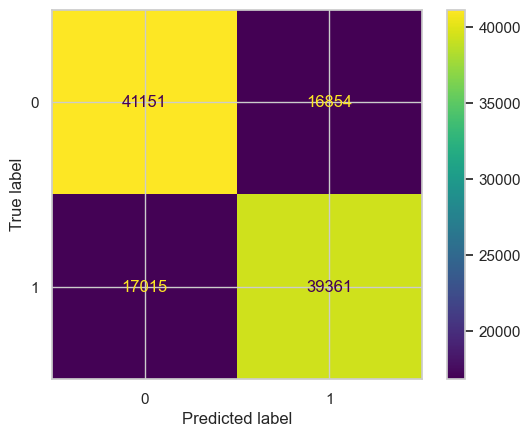

In [112]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

#### <font color='blue'>*• **Avaliação** das métricas do modelo:*</font>

In [113]:
# Avaliando o modelo pela acurácia (% Acerto, i.e.: Acertos /Total previsões). Usamos ela p/ comparar modelos do mesmo algoritmo!

accuracy = accuracy_score(y_test, y_pred)
accuracy

# A Acurácia é uma métrica global, ou seja, para todo o modelo, e é especialmente útil
# quando as classes estão balanceadas

0.7038931291036099

In [114]:
# Avaliando o modelo pela AUC (Área Sob a Curva ROC). Usamos p/ comparar diferentes algoritmos!

auc = roc_auc_score(y_test, y_pred_proba)
auc

# AUC também é uma métrica global, e mede a capacidade de separação entre as classes. 
# Ela é especialmente útil em dados desbalanceados.

0.7734955629109497

> <font color='purple'>**Acurácia** e **AUC** são **MÉTRICAS GLOBAIS**, ou seja, para todo o modelo! O ideal é que estejam acima de 70%

In [115]:
# Outras métricas importantes p/ classificação com RF

classification_rep = classification_report(y_test, y_pred)
print(classification_rep)

              precision    recall  f1-score   support

           1       0.71      0.71      0.71     58005
           2       0.70      0.70      0.70     56376

    accuracy                           0.70    114381
   macro avg       0.70      0.70      0.70    114381
weighted avg       0.70      0.70      0.70    114381



<font color='purple'>**Métricas Locais** (por classses). Pela tabela acima, podemos perceber que a **Precisão**, o **Recall** e o **F1-Score** são praticamente os mesmos (70%) em ambas as classses (**1**: com auxílio emergencial; e **2**: sem auxílio emergencial), o que comprova que o modelo está equilibrado. </font>

#### <font color='blue'>*• **Validação Cruzada** para checar a performance em cada fold:*</font>

In [116]:
# Criando um novo modelo RandomForest para validação cruzada

#dsa_modelo_cv = RandomForestClassifier(random_state = 42)

In [117]:
# Realizando a validação cruzada

# Usaremos 5 folds para a validação cruzada
#cv_scores = cross_val_score(dsa_modelo_cv, X_train_preprocessed, y_train, cv = 5)
#cv_scores

# OBS: ESTA ANÁLISE DEMOROU 8 MIN P/ SER FEITO EM MEU LENOVO CORE i5 2.40 GHz, 8Gb RAM e c/ SSD

<font color='purple'>**CONCLUSÃO:** Como a performance em cada fold **NÃO VARIA** muito, quer dizer que **EXISTE UM PADRÃO** que o modelo conseguiu capturar nos dados - **"Em diferentes amostras (folds), o modelo é consistente!"**. Estes resultados fornecem uma visão mais robusta do desempenho do modelo, pois a validação cruzada avalia a capacidade do modelo de generalizar para novos dados. A variação nas pontuações de acurácia entre os diferentes folds indicaria que o modelo poderia vir a se comportar de maneira inconsistente em diferentes subconjuntos dos dados. Isso pode ser devido a características dos dados, como desbalanceamento de classes, ou à necessidade de um ajuste mais fino dos hiperparâmetros do modelo.

## <font color='gray'>**11) Otimização de Hiperparâmetros e Versão Final do Modelo:**

#### <font color='blue'>*• Otimização de Hiperparâmetros:*</font>

In [118]:
# Definindo os hiperparâmetros para serem otimizados (dicionário python)

param_grid = {
    'n_estimators': [50, 100, 200],   # Número de árvores
    'max_depth': [None, 10, 20, 30],  # Profundidade máxima da árvore
    'min_samples_split': [2, 4, 6],   # Número mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]     # Número mínimo de amostras exigido em um nó folha
}

In [119]:
# Criando o modelo RandomForest para a otimização

dsa_modelo_opt = RandomForestClassifier(random_state = 42)


In [120]:
# Configurando a busca em grade com validação cruzada

grid_search = GridSearchCV(dsa_modelo_opt, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)


# O objeto "grid_search" criado nesta célula, é uma instância da classe GridSearchCV().
# Ele foi configurado para buscar os melhores hiperparâmetros do modelo "dsa_modelo_opt" 
# usando o dicionário "param_grid", criado na célula acima, e validação cruzada com 5 folds.

# Ele fará um cruzamento para combinar todos os possíveis valores dos hiperparâmetros escolhidos
# e guardará os melhores valores na variável "best_params_" (atributo do obj "grid_search")


In [121]:
# Realizando a otimização com o conjunto de treino

# ATENÇÃO! ESSA BUSCA PELOS MELHORES HIPERPARÂMETROS PODE SER BASTANTE DEMORADA
# A DEPENDER DO NRO DE VARIÁVEIS ENVOLVIDAS E DO NRO DE HIPERPARÂMETROS USADOS
# TENHA MUUUUITA PACIÊNCIAAAAAAAAAAAA


#grid_search.fit(X_train_preprocessed, y_train)


# PS:
# Dimensões X_train_preprocessed (shape): 266.889 x 149  (70% dos dados originais p/ TREINO) 

# Número de árvores (n_estimators): [50, 100, 200]
# Profundidade máxima da árvore (max_depth): [None, 10, 20, 30]
# Número mínimo de amostras para dividir um nó (min_samples_split): [2, 4, 6]  
# Número mínimo de amostras exigido em um nó folha (min_samples_leaf): [1, 2, 4]

# OBS: ESTA OTIMIZAÇÃO DEMOROU 285 MIN (4:45h) P/ SER FEITA EM MEU LENOVO CORE i5 2.40 GHz, 8Gb RAM e c/ SSD !!!!!!!!!!


In [122]:
# Melhores parâmetros e pontuação

#best_params = grid_search.best_params_
#best_score = grid_search.best_score_

In [123]:
#best_params, best_score

<font color = 'purple'>**PS:** A título de curiosidade, os melhores hiperparâmetros encontrados durante a otimização nesse conjunto de dados foram:


<font color = 'purple'>max_depth: 30


<font color = 'purple'>min_samples_leaf: 2


<font color = 'purple'>min_samples_split: 2


<font color = 'purple'>n_estimators: 200

(Deixamos comentadas estas células pois essa otimização foi muito demorada para ser feita!)

#### <font color='blue'>*• Versão Final do Modelo:*</font>

In [124]:
# Criando o modelo RandomForest com os melhores hiperparâmetros

#dsa_modelo_final = RandomForestClassifier(n_estimators = best_params['n_estimators'],
#                                          max_depth = best_params['max_depth'],
#                                          min_samples_split = best_params['min_samples_split'],
#                                          min_samples_leaf = best_params['min_samples_leaf'],
#                                          random_state = 42)

In [125]:
# Treinando o modelo final com o conjunto de treino

#dsa_modelo_final.fit(X_train_preprocessed, y_train)

# OBS: ESTE TREINAMENTO DEMOROU 2 MIN P/ SER FEITO EM MEU LENOVO CORE i5 2.40 GHz, 8Gb RAM e c/ SSD

In [126]:
# Previsões com dados de teste

#y_pred_final = dsa_modelo_final.predict(X_test_preprocessed)
#y_pred_final

In [127]:
# Mesmo array anterior, mas contendo as probabilidades das previsões

#y_pred_proba_final = dsa_modelo_final.predict_proba(X_test_preprocessed)[:,1]
#y_pred_proba_final

In [128]:
# tabela com a contagem das previsões iguais a 1 e 2

#pd.Series(y_pred_final).value_counts()

In [129]:
# Avaliando a acurácia do modelo final no conjunto de teste

#final_accuracy = accuracy_score(y_test, y_pred_final)
#final_accuracy

In [130]:
# Avaliando o modelo final pela AUC (Área Sob a Curva ROC)

#final_auc = roc_auc_score(y_test, y_pred_proba_final)
#final_auc

In [131]:
#final_classification_report = classification_report(y_test, y_pred_final)
#print(final_classification_report)

> <font color='purple'>Com a Otimização dos Hiperparâmetros, conseguimos melhorar a **Acurácia** do modelo em **1,89%**</font> <font color='red'>**(nova acurácia: 72,27)**</font><font color='purple'> e melhoramos a **AUC** em **2,62%** </font> <font color='blue'> **(nova AUC: 79,97)**</font>.

> <font color='purple'>Mas, como o tpo de execução desta Otimização de Hiperparâmetros ficou longo e o ganho percentual foi baixo, optamos por deixar comentadas  as linhas desta Seção 11 (Otimização), e vamos seguir adiante com o modelo **dsa_modelo_v1** com </font> <font color='red'>**70,39% de acurácia** </font> <font color='purple'> e </font><font color='blue'>**77,35% de AUC**! </font>

<font color = 'purple'>**PS:** Se quiser, crie uma **versão 2** do modelo com os hiperparâmetros que havíamos encontrado:


<font color = 'purple'>max_depth: 30


<font color = 'purple'>min_samples_leaf: 2


<font color = 'purple'>min_samples_split: 2


<font color = 'purple'>n_estimators: 200

## <font color='green'>->**SALVAMENTO/ DEPLOY DO MODELO:**

In [132]:
#joblib.dump(dsa_modelo_final, "./modelos/dsa_modelo_final.pkl")  #Não vamos optar pela Otimização de Hiperparâmetros
joblib.dump(dsa_modelo_v1, "./modelos/dsa_modelo_v1.pkl")


['./modelos/dsa_modelo_v1.pkl']

In [133]:
joblib.dump(scaler, "./modelos/dsa_padronizador.pkl")

['./modelos/dsa_padronizador.pkl']

In [134]:
print(X_train_preprocessed.shape)
X_train_preprocessed.head()

(266889, 149)


,SALARIO,VALOR_TICKET-CESTA,SOMA_APOSENTADORIAS+PENSAO,D0023,SOMA_BOLSAS_FAMILIA,SOMA_BPC-LOAS,SOMA_SEGUROS_DESEMPREGO,D0073,UF_AC,UF_AL,...,C007D_99.0,C010_1.0,C010_99.0,SOMENTE_BENEFICIO_N/A,SOMENTE_BENEFICIO_Sim,NAO_REMUNERADO_N/A,NAO_REMUNERADO_Sim,C014_1.0,C014_2.0,C014_99.0
0,0.106581,-0.032049,0.143776,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
1,-0.386797,-0.032049,0.143776,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,0.925286,-0.743165
2,0.132548,-0.032049,-0.432151,-0.129761,-0.270754,4.805993,-0.136021,-0.122749,7.412933,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597
3,-0.386797,-0.032049,-0.432151,-0.129761,3.165902,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,0.781632,-0.787321,0.787321,0.014487,-0.014487,0.090917,-0.090917,-0.343355,-1.080747,1.345597
4,-0.009092,-0.032049,0.719703,-0.129761,-0.270754,-0.179414,-0.136021,-0.122749,-0.134899,-0.18081,...,-1.279375,1.270129,-1.270129,0.014487,-0.014487,0.090917,-0.090917,2.912440,-1.080747,-0.743165


## <font color='green'>->**CARREGANDO E TESTANDO O MODELO/PADRONIZADOR SALVOS:**

In [135]:
# Carregando o modelo e o padronizador (scaler)

modelo_carregado = joblib.load("./modelos/dsa_modelo_v1.pkl")
scaler_carregado = joblib.load("./modelos/dsa_padronizador.pkl")

In [136]:
# Exportando (CSV) a tabela q havia sido criada c/ o One-Hot Encoding antes da padronização (para simular novos dados):
# (mesmo código da célula 95 deste JupyterNobebook)

X_train_preprocessed = X_train.drop(categorical_cols, axis = 1).reset_index(drop = True)
X_train_preprocessed = pd.concat([X_train_preprocessed, X_train_encoded], axis = 1)
X_train_preprocessed.to_csv("./dados/NOVOS_DADOS_N_PADRONIZADOS.csv", \
                            index = False, encoding = 'utf-8')

In [137]:
# Carregando os novos dados em um DataFrame do Pandas

df_novos_dados = pd.read_csv("./dados/NOVOS_DADOS_N_PADRONIZADOS.csv")
print(df_novos_dados.shape)

(266889, 149)


In [138]:
# Padronizando os novos dados com o scaler (padronizador) q acabamos de carregar na memória ('scaler_carregado'), 
# e fazendo o 'deploy' (previsões) via linha de comando

novos_dados_padronizados = scaler_carregado.transform(df_novos_dados)
y_pred = modelo_carregado.predict(novos_dados_padronizados)
print(y_pred)

[1 1 2 ... 2 1 1]


In [139]:
%watermark -a "Christopherson B. Francischetti"

Author: Christopherson B. Francischetti



In [140]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.9.13
IPython version      : 7.31.1

Compiler    : MSC v.1916 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
CPU cores   : 8
Architecture: 64bit



In [141]:
%watermark --iversions

sklearn   : 1.3.2
numpy     : 1.26.3
seaborn   : 0.13.1
pandas    : 2.1.4
matplotlib: 3.8.2
joblib    : 1.3.2



# <font color='RED'>Fim